# Set Up and Configuration

In [29]:
# Kaggle notebook setup
import os

BASE_DIR = "/kaggle/working/led_project"
DATASET_DIR = os.path.join(BASE_DIR, "datasets")

os.makedirs(DATASET_DIR, exist_ok=True)

# Toggle: True -> skip training if checkpoint exists, load from disk
#         False -> always retrain from scratch
USE_CHECKPOINTS = True

print("Kaggle environment ready!")
print(f"USE_CHECKPOINTS = {USE_CHECKPOINTS}")

Kaggle environment ready!
USE_CHECKPOINTS = True


In [30]:
import shutil, glob
for f in glob.glob('/kaggle/input/datasets/asmaraliyeva/gtsrb-weights/gtsrb-weights/*'):
    shutil.copy(f, BASE_DIR)
print(os.listdir(BASE_DIR))

['macro_f1_table.csv', 'sw_at_elle_history.png', 'fgsm_at_elle_history.json', 'pgd_at_history.json', 'best_epochs.json', 'cross_dataset.csv', 'mobilenetv2_gtsrb.pth', 'pgd_at_history.png', 'resnet18_gtsrb_history.json', 'fgsm_at.pth', 'fig7_gradcam_critical.png', 'wscer_table.csv', 'mobilenetv2_training_curves.png', 'sw_at_elle.pth', 'matrix_5x3.csv', 'config.yaml', 'mobilenetv2_gtsrb_history.json', 'fgsm_at_elle.pth', 'fgsm_at_elle_history.png', 'datasets', 'baselines_comparison_curves.png', 'confusion_safety_8x8.png', 'fig4_class_size_vs_robustness.png', 'fgsm_at_history.png', 'fig6_gradcam_3x3.png', 'fgsm_at_history.json', 'pgd_at.pth', 'fig8_safety_8x8.png', 'fig10_wscer.png', 'sw_at_elle_history.json', 'resnet18_gtsrb.pth', 'fig1_class_distribution.png', 'fig3_fgsm_vs_pgd.png', 'per_class_accuracy.csv', 'fig5_matrix_bars.png', 'confusion_full_43.png']


In [31]:
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import random
import numpy as np
import time
import os
import matplotlib.ticker as mticker
import subprocess
import zipfile
import pandas as pd
from collections import Counter
from sklearn.metrics import classification_report

# IMPORTANT: install without changing Kaggle CUDA/Torch packages
%pip install -q --no-deps torchattacks

import torchattacks

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Note: you may need to restart the kernel to use updated packages.
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [32]:
# Write training config to disk (YAML)
config_yaml = """
dataset:
  mean: [0.3337, 0.3064, 0.3171]
  std:  [0.2672, 0.2564, 0.2629]
  root: /kaggle/working/led_project/datasets
  num_classes: 43
  img_size: 64

training:
  batch_size: 32
  test_batch_size: 64
  epochs: 30
  lr: 0.1
  momentum: 0.9
  weight_decay: 0.0005
  seed: 42

model:
  name: resnet18
"""

with open('/kaggle/working/led_project/config.yaml', 'w') as f:
    f.write(config_yaml)
print("Config saved!")

Config saved!


In [33]:
# GTSRB class labels (43 total, ordered by class ID)
classes = [
    "Speed limit 20",      # 0
    "Speed limit 30",      # 1
    "Speed limit 50",      # 2
    "Speed limit 60",      # 3
    "Speed limit 70",      # 4
    "Speed limit 80",      # 5
    "End speed limit 80",  # 6
    "Speed limit 100",     # 7
    "Speed limit 120",     # 8
    "No passing",          # 9
    "No passing >3.5t",    # 10
    "Right of way",        # 11
    "Priority road",       # 12
    "Yield",               # 13
    "Stop",                # 14
    "No vehicles",         # 15
    "No vehicles >3.5t",   # 16
    "No entry",            # 17
    "General caution",     # 18
    "Dangerous curve left",# 19
    "Dangerous curve right",#20
    "Double curve",        # 21
    "Bumpy road",          # 22
    "Slippery road",       # 23
    "Road narrows right",  # 24
    "Road work",           # 25
    "Traffic signals",     # 26
    "Pedestrians",         # 27
    "Children crossing",   # 28
    "Bicycles crossing",   # 29
    "Ice/snow",            # 30
    "Wild animals",        # 31
    "End restrictions",    # 32
    "Turn right ahead",    # 33
    "Turn left ahead",     # 34
    "Ahead only",          # 35
    "Straight or right",   # 36
    "Straight or left",    # 37
    "Keep right",          # 38
    "Keep left",           # 39
    "Roundabout",          # 40
    "End no passing",      # 41
    "End no passing >3.5t" # 42
]

for i, name in enumerate(classes):
    print(f"{i:2d}: {name}")

print(f"\nTotal: {len(classes)} classes")

 0: Speed limit 20
 1: Speed limit 30
 2: Speed limit 50
 3: Speed limit 60
 4: Speed limit 70
 5: Speed limit 80
 6: End speed limit 80
 7: Speed limit 100
 8: Speed limit 120
 9: No passing
10: No passing >3.5t
11: Right of way
12: Priority road
13: Yield
14: Stop
15: No vehicles
16: No vehicles >3.5t
17: No entry
18: General caution
19: Dangerous curve left
20: Dangerous curve right
21: Double curve
22: Bumpy road
23: Slippery road
24: Road narrows right
25: Road work
26: Traffic signals
27: Pedestrians
28: Children crossing
29: Bicycles crossing
30: Ice/snow
31: Wild animals
32: End restrictions
33: Turn right ahead
34: Turn left ahead
35: Ahead only
36: Straight or right
37: Straight or left
38: Keep right
39: Keep left
40: Roundabout
41: End no passing
42: End no passing >3.5t

Total: 43 classes


### Safety severity groups

In [34]:
# Safety severity groups
SAFETY_WEIGHTS = {
    "fatal": 4,
    "dangerous": 3,
    "moderate": 2,
    "minor": 1
}

SAFETY_CLASSES = {
    "fatal":     [14, 17],
    "dangerous": [13, 27, 28, 29],
    "moderate":  [0, 1, 2, 3, 4, 5, 7, 8],
    "minor":     [6, 9, 10, 11, 12, 15, 16, 18, 19, 20,
                  21, 22, 23, 24, 25, 26, 30, 31, 32, 33,
                  34, 35, 36, 37, 38, 39, 40, 41, 42]
}
print("Safety groups defined.")

Safety groups defined.


In [35]:
# Load config and expose values as module-level constants
import yaml

with open('/kaggle/working/led_project/config.yaml') as f:
    cfg = yaml.safe_load(f)

MEAN            = cfg['dataset']['mean']
STD             = cfg['dataset']['std']
IMG_SIZE        = cfg['dataset']['img_size']
ROOT            = cfg['dataset']['root']
NUM_CLASSES     = cfg['dataset']['num_classes']
LR              = cfg['training']['lr']
EPOCHS          = cfg['training']['epochs']
BATCH_SIZE      = cfg['training']['batch_size']
TEST_BATCH_SIZE = cfg['training']['test_batch_size']
MOMENTUM        = cfg['training']['momentum']
WEIGHT_DECAY    = cfg['training']['weight_decay']
SEED            = cfg['training']['seed']
EPSILONS       = [0, 2/255, 4/255, 8/255, 16/255, 32/255]
EPSILON_LABELS = ['0', '2/255', '4/255', '8/255', '16/255', '32/255']

In [36]:
# Set all seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
print(f"Seed set to {SEED}")

Seed set to 42


In [37]:
# Initialize ResNet-18 baseline (Model A) on the selected device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights=None, num_classes=NUM_CLASSES)
model = model.to(device)

print(f"Using: {device}")

Using: cuda


In [38]:
# Train transform: WITH augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomCrop(IMG_SIZE, padding=4),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Test transform: NO augmentation
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

In [39]:
# Build GTSRB train DataLoader
trainset = torchvision.datasets.GTSRB(
    root=ROOT,
    split='train',
    download=True,
    transform=train_transform
)

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

In [40]:
# Download test split
dataset_dir = '/kaggle/working/led_project/datasets/gtsrb'
os.makedirs(dataset_dir, exist_ok=True)

# Download test images and ground truth labels separately
!wget --quiet "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip" -O /kaggle/working/test_images.zip
!wget --quiet "https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip" -O /kaggle/working/test_gt.zip

# Extract both archives into dataset directory
with zipfile.ZipFile('/kaggle/working/test_images.zip', 'r') as z:
    z.extractall(dataset_dir)

with zipfile.ZipFile('/kaggle/working/test_gt.zip', 'r') as z:
    z.extractall(dataset_dir)

print("Test split downloaded and extracted successfully!")

Test split downloaded and extracted successfully!


In [41]:
# Build GTSRB test DataLoader
testset = torchvision.datasets.GTSRB(
    root=ROOT,
    split='test',
    download=False,
    transform=test_transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Train samples: {len(trainset)}")
print(f"Test samples:  {len(testset)}")

Train samples: 26640
Test samples:  12630


# Analysis of Dataset GTSRB

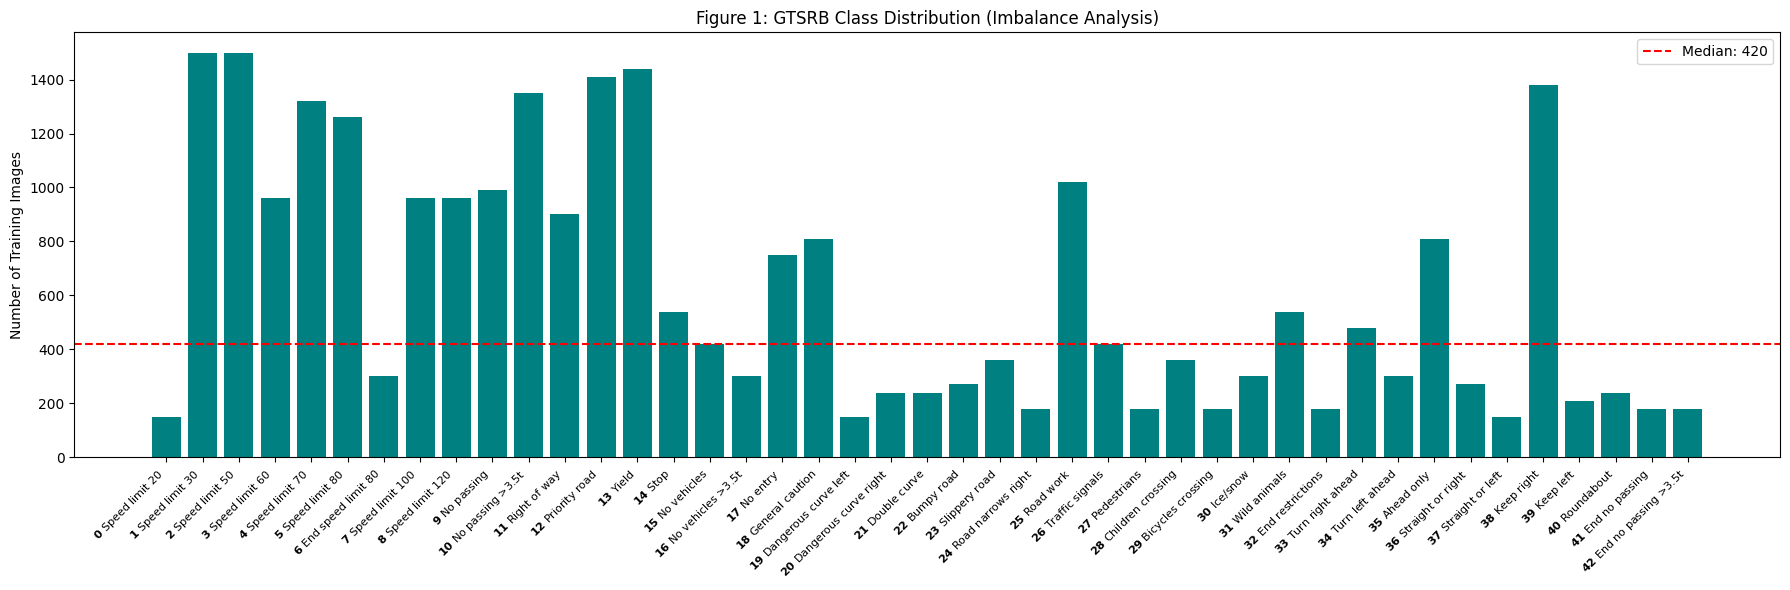

Most frequent class:  Speed limit 30 (1500 samples)
Least frequent class: Speed limit 20 (150 samples)
Median: 420 samples
Imbalance ratio (max/min): 10.0x


In [42]:
# ==========================================
# Figure 1: GTSRB class distribution (imbalance analysis)
# ==========================================
import pandas as pd
from collections import Counter

train_labels = [label for _, label in trainset._samples]   # labels only, no image decoding
counts = Counter(train_labels)
class_counts = pd.DataFrame([
    {'Class_ID': i, 'Name': classes[i], 'Count': counts[i]}
    for i in range(len(classes))
])

# Bold class number + plain name for x-axis labels
labels_bold = [r'$\bf{' + str(int(cid)) + r'}$ ' + name
               for cid, name in zip(class_counts['Class_ID'], class_counts['Name'])]

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(range(len(class_counts)), class_counts['Count'], color='teal')

median_val = class_counts['Count'].median()
ax.axhline(y=median_val, color='r', linestyle='--', label=f'Median: {int(median_val)}')

ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(labels_bold, rotation=45, ha='right', fontsize=8)
ax.set_title('Figure 1: GTSRB Class Distribution (Imbalance Analysis)')
ax.set_ylabel('Number of Training Images')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig1_class_distribution.png'), dpi=120, bbox_inches='tight')
plt.show()

# Find actual most/least frequent classes by Count value
# (NOT by row position — DataFrame is unsorted, so iloc[0]/iloc[-1] gives wrong answer)
most_row  = class_counts.loc[class_counts['Count'].idxmax()]
least_row = class_counts.loc[class_counts['Count'].idxmin()]

print(f"Most frequent class:  {most_row['Name']} ({most_row['Count']} samples)")
print(f"Least frequent class: {least_row['Name']} ({least_row['Count']} samples)")
print(f"Median: {int(median_val)} samples")
print(f"Imbalance ratio (max/min): {most_row['Count'] / least_row['Count']:.1f}x")

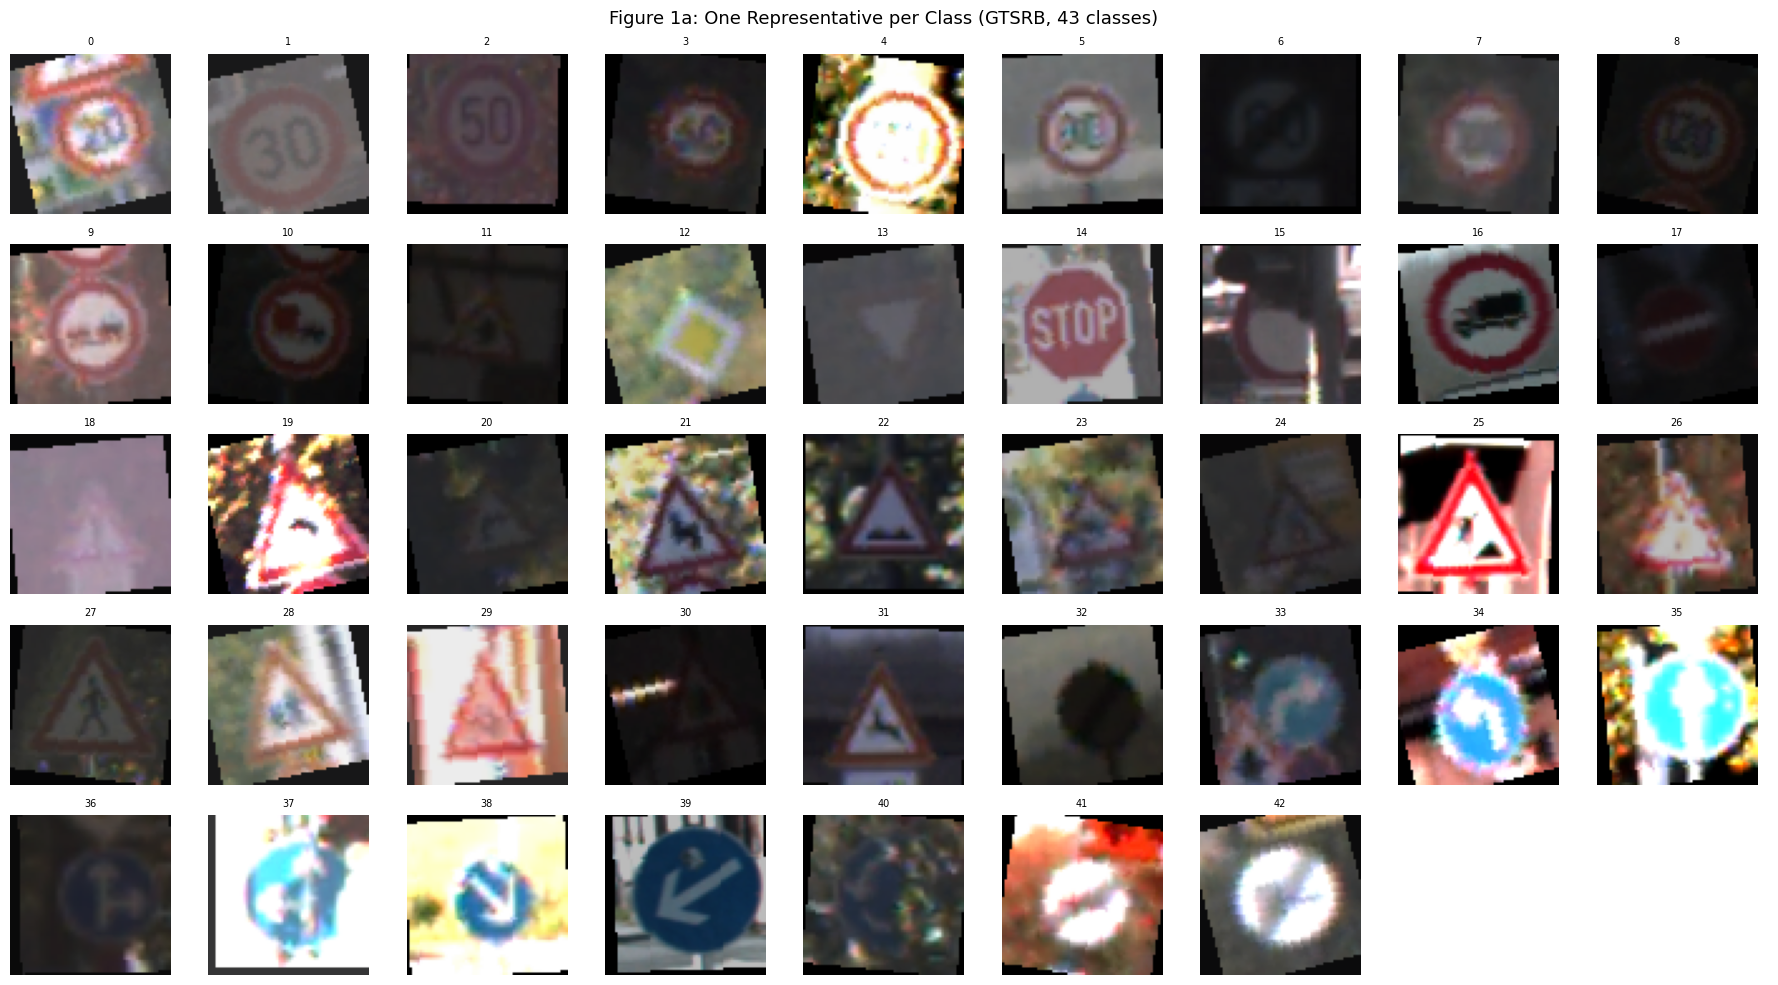

In [43]:
# ==========================================
# One Representative per Class
# ==========================================

# Build a dictionary mapping each class label → dataset index of its first occurrence
# We only need one image per class, so we stop once all 43 classes are found
class_examples = {}
for idx, (_, label) in enumerate(trainset._samples):   # labels only, no image decoding
    if label not in class_examples:
        class_examples[label] = idx  # Store the index, not the image itself (memory efficient)
    if len(class_examples) == NUM_CLASSES:
        break  # Early exit — no need to scan the rest of the dataset

# Set up a 5x9 grid = 45 slots to display all 43 classes (2 slots will remain empty)
n_cols = 9
n_rows = 5
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))

for idx, ax in enumerate(axes.flat):
    if idx < NUM_CLASSES:
        # Retrieve the image and its label using the stored dataset index
        img, label = trainset[class_examples[idx]]

        # Convert from (C, H, W) tensor → (H, W, C) numpy array for matplotlib
        img = img.permute(1, 2, 0).numpy()

        # Reverse normalization: pixel = (normalized_pixel * STD) + MEAN
        # This restores the original [0, 1] color range for correct display
        img = np.array(STD) * img + np.array(MEAN)

        # Clamp values to [0, 1] to avoid display artifacts from floating point errors
        img = np.clip(img, 0, 1)

        ax.imshow(img)
        ax.set_title(f'{idx}', fontsize=7)  # Show class ID as title
        ax.axis('off')                       # Hide axes ticks and borders
    else:
        # Hide the 2 unused slots in the last row (slots 43 and 44)
        ax.axis('off')

plt.suptitle('Figure 1a: One Representative per Class (GTSRB, 43 classes)', fontsize=13)
plt.tight_layout()
plt.show()

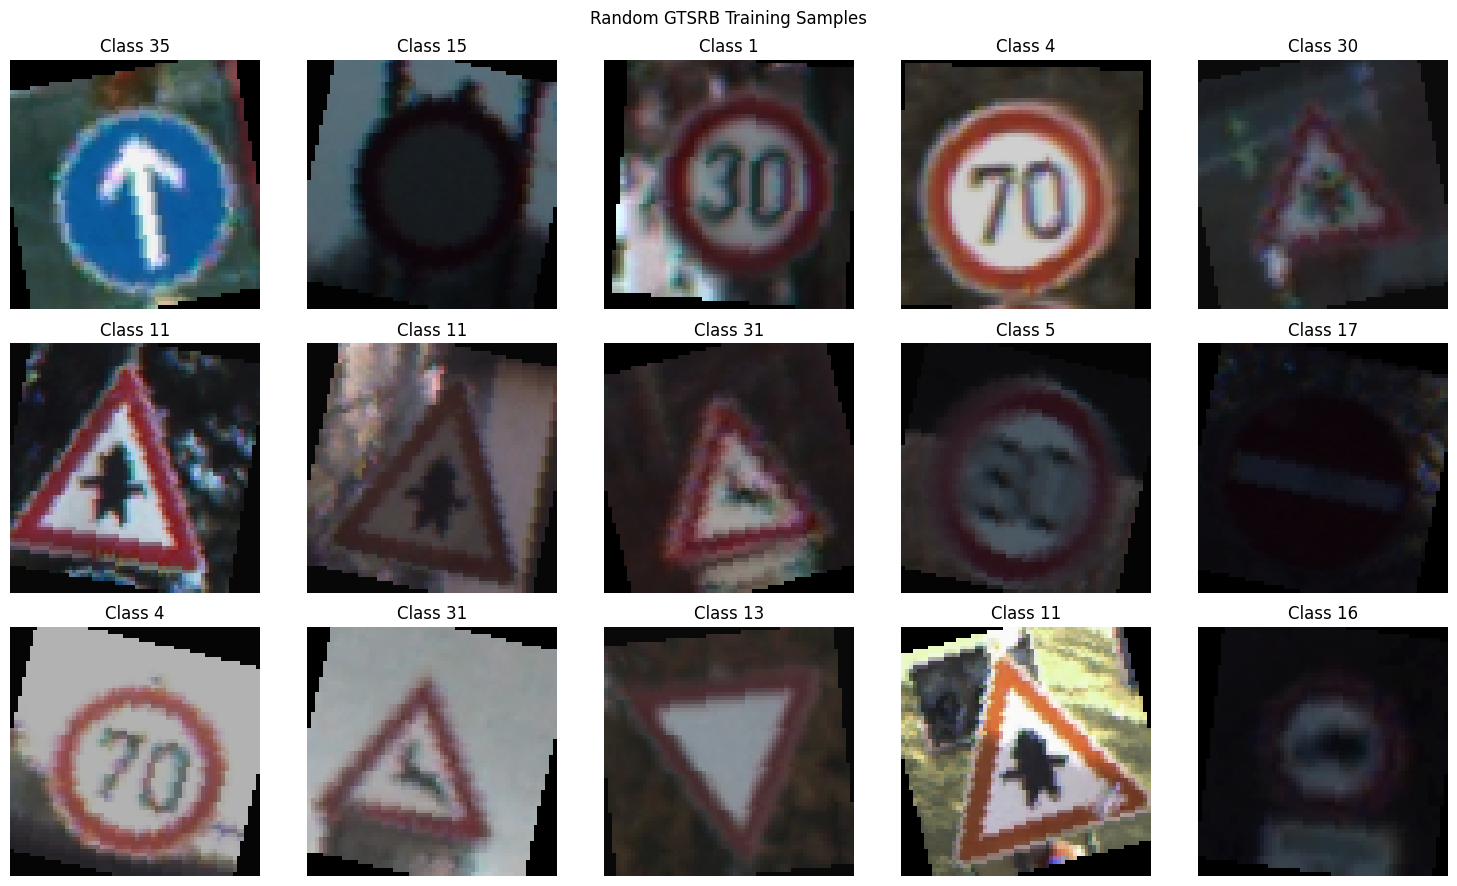

In [44]:
# ==========================================
# Visualize Random Training Images
# ==========================================

# Create a 3x5 grid = 15 subplots to display random training samples
fig, axes = plt.subplots(3, 5, figsize=(15, 9))

for ax in axes.flat:
    # Pick a random index from the training set each iteration
    idx = np.random.randint(len(trainset))

    # Load image (C, H, W tensor) and its class label
    image, label = trainset[idx]

    # Convert from (C, H, W) tensor → (H, W, C) numpy array for matplotlib
    image = image.permute(1, 2, 0).numpy()

    # Reverse the normalization applied during preprocessing:
    # original_pixel = (normalized_pixel * std) + mean
    # These values match the GTSRB dataset statistics used in transforms
    mean = np.array([0.3337, 0.3064, 0.3171])
    std  = np.array([0.2672, 0.2564, 0.2629])
    image = std * image + mean

    # Clamp to [0, 1] to prevent display artifacts from floating point drift
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(f"Class {label}")
    ax.axis("off")  # Hide axes ticks and borders for cleaner visualization

plt.suptitle("Random GTSRB Training Samples")
plt.tight_layout()
plt.show()

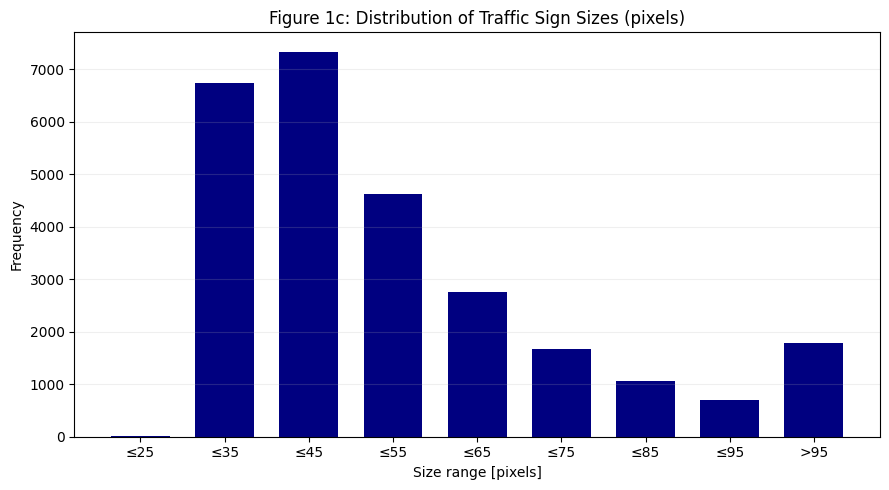

Total images analyzed: 26640
Min size: 25px   Max size: 243px
Most common range: ≤45


In [45]:
# ==========================================
# Figure 1c: Distribution of Traffic Sign Sizes
# ==========================================
from PIL import Image
import torchvision

# Load raw dataset without transforms to get original image sizes
trainset_sizes = torchvision.datasets.GTSRB(
    root=ROOT,
    split='train',
    download=False,
    transform=None  # no transform — we want original sizes
)

# Collect the larger dimension of each image
sign_sizes = []
for img, _ in trainset_sizes:
    w, h = img.size
    sign_sizes.append(max(w, h))

# Define size bins matching Stallkamp paper
bins   = [0, 25, 35, 45, 55, 65, 75, 85, 95, float('inf')]
labels = ['≤25', '≤35', '≤45', '≤55', '≤65', '≤75', '≤85', '≤95', '>95']

counts_size = [0] * len(labels)
for s in sign_sizes:
    for i in range(len(bins) - 1):
        if bins[i] < s <= bins[i+1]:
            counts_size[i] += 1
            break

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(labels)), counts_size, color='navy', width=0.7)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_xlabel('Size range [pixels]')
ax.set_ylabel('Frequency')
ax.set_title('Figure 1c: Distribution of Traffic Sign Sizes (pixels)')
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print(f"Total images analyzed: {len(sign_sizes)}")
print(f"Min size: {min(sign_sizes)}px   Max size: {max(sign_sizes)}px")
print(f"Most common range: {labels[counts_size.index(max(counts_size))]}")

In [46]:
from collections import Counter

# Class weights: inverse frequency so rare classes get higher loss weight
_counts = Counter([label for _, label in trainset._samples])   # labels only, no image decoding
_weights = torch.FloatTensor([1.0 / _counts[i] for i in range(NUM_CLASSES)]).to(device)
criterion = nn.CrossEntropyLoss(weight=_weights)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("Weighted loss ready. Min weight: {:.5f}  Max weight: {:.5f}".format(
    _weights.min().item(), _weights.max().item()))

Weighted loss ready. Min weight: 0.00067  Max weight: 0.00667


# Standard Training

## ResNet-18 Baseline

In [47]:
# ==========================================
# Checkpoint loader — used by all training cells below.
# If USE_CHECKPOINTS=True and the .pth file exists, weights are restored
# and training is skipped. Otherwise the caller trains from scratch.
# ==========================================
import json as _json  

def try_load_checkpoint(model, ckpt_name, history_name=None):
    """
    Attempts to restore model weights and training history from disk.

    Args:
        model        : The PyTorch model whose weights will be restored.
        ckpt_name    : Filename of the .pth checkpoint (relative to BASE_DIR).
        history_name : Optional filename of the JSON training history file.

    Returns:
        (loaded, history_dict)
        - loaded=True  → weights restored, skip training; history dict returned (or None)
        - loaded=False → checkpoint not found or disabled; caller should train from scratch
    """

    # If checkpointing is globally disabled, always train from scratch
    if not USE_CHECKPOINTS:
        return False, None

    # Build the full path and check if the checkpoint file actually exists
    ckpt_path = os.path.join(BASE_DIR, ckpt_name)
    if not os.path.exists(ckpt_path):
        return False, None  # File missing — caller must train

    # Restore saved weights; map_location=device handles CPU/GPU portability
    # (e.g. a checkpoint saved on GPU can be loaded on a CPU-only machine)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.eval()  # Set to eval mode by default; caller switches to train() if needed

    # Optionally restore training history (loss curves, accuracy logs, etc.)
    history = None
    if history_name is not None:
        hist_path = os.path.join(BASE_DIR, history_name)
        if os.path.exists(hist_path):
            with open(hist_path) as f:
                history = _json.load(f)

    # Confirm what was loaded so the notebook output is traceable
    print(f"Loaded {ckpt_name}" + (f" (+ {history_name})" if history else ""))
    return True, history

print("Checkpoint loader ready.")

Checkpoint loader ready.


In [48]:
# ==========================================
# Early Stopping Tracker class — used by all training cells below.
# Tracks best epoch by validation accuracy; does NOT stop the loop early.
# (Training always runs for the full number of epochs — this class only
#  records when the best checkpoint occurred and warns if it has plateaued.)
# ==========================================

class EarlyStoppingTracker:
    def __init__(self, patience=5):
        """
        Args:
            patience : Number of consecutive epochs without improvement
                       before flagging convergence. Default is 5.
        """
        self.patience   = patience
        self.best_acc   = 0.0   # Best validation accuracy seen so far
        self.best_epoch = 0     # Epoch index (0-based) at which best_acc occurred
        self.no_improve = 0     # Counter of consecutive non-improving epochs
        self.converged  = False # Flipped to True once patience is exhausted (fires once)

    def step(self, acc, epoch):
        """
        Call once per epoch with the current validation accuracy.

        Args:
            acc   : Validation accuracy for the current epoch (float, e.g. 98.5).
            epoch : Current epoch index (0-based).

        Returns:
            'IMPROVED'   — new best accuracy was set this epoch.
            'NO_IMPROVE' — accuracy did not beat the current best.
        """
        if acc > self.best_acc:
            # New best found — reset the no-improvement counter
            self.best_acc   = acc
            self.best_epoch = epoch
            self.no_improve = 0
            return 'IMPROVED'
        else:
            self.no_improve += 1

            # Fire the convergence warning exactly once when patience runs out
            if self.no_improve >= self.patience and not self.converged:
                self.converged = True
                print(
                    f'  [EarlyStopping] No improvement for {self.patience} epochs. '
                    f'Best was epoch {self.best_epoch + 1} ({self.best_acc:.1f}%)'
                )
            return 'NO_IMPROVE'

# Global registry of best epochs across all training runs in this notebook session.
# Populated by each training cell so results can be compared in a summary cell.
# 'dir()' check prevents resetting the list if this cell is re-run mid-session.
if 'all_best_epochs' not in dir():
    all_best_epochs = []

In [49]:
# ==========================================
# Train ResNet-18 baseline OR restore from checkpoint
# ==========================================

# Attempt to load saved weights + history from disk.
# If successful, all training below is skipped entirely.
loaded, hist = try_load_checkpoint(model, 'resnet18_gtsrb.pth', 'resnet18_gtsrb_history.json')

if loaded:
    # ── Checkpoint found: reconstruct history so downstream cells work ──
    train_losses   = hist['train_losses']
    val_accuracies = hist['val_accuracies']

    # Reconstruct a minimal tracker object from saved metadata using an
    # anonymous class — avoids re-running EarlyStoppingTracker from scratch
    es_tracker = type('obj', (), {
        'best_epoch': hist.get('best_epoch', len(val_accuracies)) - 1,  # 0-based
        'best_acc':   hist.get('best_acc',   val_accuracies[-1]),
    })()
    print(f"Best epoch: {es_tracker.best_epoch + 1}, best acc: {es_tracker.best_acc:.2f}%")

else:
    # ── No checkpoint: train from scratch ────────────────────────────────
    train_losses   = []   # Average training loss per epoch
    val_accuracies = []   # Test-set accuracy (%) per epoch
    es_tracker     = EarlyStoppingTracker(patience=5)
    best_state     = None  # Will hold a CPU copy of the best model weights

    n_batches = len(trainloader)

    # Print training configuration summary before starting
    print('=' * 60)
    print(f' RESNET-18 BASELINE  |  {EPOCHS} epochs  |  {n_batches} batches/epoch')
    print(f' Train samples: {len(trainset)}   Test samples: {len(testset)}')
    print(f' Image size: {IMG_SIZE}x{IMG_SIZE}   Batch size: {BATCH_SIZE}')
    print('=' * 60)

    t_total = time.time()  # Wall-clock timer for total training duration

    for epoch in range(EPOCHS):
        t_ep = time.time()  # Per-epoch timer
        model.train()       # Enable dropout / batch-norm training behaviour
        total_loss = 0

        # ── Training loop ─────────────────────────────────────────────
        for b_idx, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()                        # Clear gradients from previous batch
            loss = criterion(model(images), labels)      # Forward pass + compute loss
            loss.backward()                              # Backprop: compute gradients
            optimizer.step()                             # Update weights
            total_loss += loss.item()

            # Print progress ~5 times per epoch (every 20% of batches)
            if (b_idx + 1) % max(1, n_batches // 5) == 0:
                print(f'    [Epoch {epoch+1:02d}] batch {b_idx+1:4d}/{n_batches}  '
                      f'running_loss={total_loss/(b_idx+1):.3f}')

        # Advance the LR scheduler at the end of each epoch (CosineAnnealing)
        scheduler.step()

        # ── Validation loop ───────────────────────────────────────────
        model.eval()   # Disable dropout / use running stats for batch-norm
        correct = total = 0
        with torch.no_grad():  # No gradients needed for evaluation — saves memory
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                preds = model(images).argmax(dim=1)        # Predicted class indices
                correct += (preds == labels).sum().item()  # Count correct predictions
                total   += labels.size(0)

        # Compute and record epoch-level metrics
        epoch_loss = total_loss / n_batches
        epoch_acc  = 100 * correct / total
        train_losses.append(epoch_loss)
        val_accuracies.append(epoch_acc)

        # Notify the early stopping tracker; returns 'IMPROVED' or 'NO_IMPROVE'
        flag = es_tracker.step(epoch_acc, epoch)

        # If this is the best epoch so far, snapshot the weights to CPU memory.
        # Storing on CPU avoids doubling GPU memory usage during training.
        if flag == 'IMPROVED':
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}

        # Gather logging metadata for this epoch
        cur_lr  = optimizer.param_groups[0]['lr']
        ep_time = time.time() - t_ep
        tag     = ' <- new best' if flag == 'IMPROVED' else ''

        # Log every 5th epoch AND any epoch that sets a new best accuracy
        if (epoch + 1) % 5 == 0 or flag == 'IMPROVED':
            print(f'  Epoch {epoch+1:02d}/{EPOCHS} | loss={epoch_loss:.3f} | '
                  f'acc={epoch_acc:.2f}% | lr={cur_lr:.4f} | {ep_time:.1f}s' + tag)

    # ── Post-training: restore best checkpoint ────────────────────────
    # The final epoch is rarely the best one — restoring best_state ensures
    # that all downstream evaluation and saving uses the peak-accuracy weights
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best weights from epoch {es_tracker.best_epoch + 1}")

    total_time = time.time() - t_total
    print('=' * 60)
    print(f' DONE  |  total {total_time/60:.1f} min  |  best epoch '
          f'{es_tracker.best_epoch + 1}  |  best acc {es_tracker.best_acc:.2f}%')
    print('=' * 60)

# ── Cross-run tracking ────────────────────────────────────────────────────────
# Append this run's best epoch to the global registry (defined in the tracker cell).
# Useful for comparing convergence speed across different model configurations.
all_best_epochs.append(es_tracker.best_epoch + 1)
print(f'Average best epoch across {len(all_best_epochs)} run(s): '
      f'{sum(all_best_epochs)/len(all_best_epochs):.1f}')

Loaded resnet18_gtsrb.pth (+ resnet18_gtsrb_history.json)
Best epoch: 26, best acc: 98.40%
Average best epoch across 1 run(s): 26.0


In [50]:
# ==========================================
# Save Model + Training Metrics
# Saves the BEST-epoch weights (model was restored from best_state above).
# Metrics include best_epoch and best_acc so the checkpoint can be reloaded.
# ==========================================

import json as _json

# Model weights — already best-epoch state thanks to best_state restore above
torch.save(model.state_dict(), os.path.join(BASE_DIR, "resnet18_gtsrb.pth"))

# Training metrics as JSON — full enough for try_load_checkpoint to reconstruct es_tracker
metrics = {
    "train_losses":   train_losses,
    "val_accuracies": val_accuracies,
    "epochs":         EPOCHS,
    "img_size":       IMG_SIZE,
    "final_acc":      val_accuracies[-1],
    "best_epoch":     es_tracker.best_epoch + 1,
    "best_acc":       es_tracker.best_acc,
}
with open(os.path.join(BASE_DIR, "resnet18_gtsrb_history.json"), "w") as f:
    _json.dump(metrics, f, indent=2)

print(f"Model saved  -> {BASE_DIR}/resnet18_gtsrb.pth")
print(f"Metrics saved -> {BASE_DIR}/resnet18_gtsrb_history.json")
print(f"  best_epoch = {metrics['best_epoch']}, best_acc = {metrics['best_acc']:.2f}%")

Model saved  -> /kaggle/working/led_project/resnet18_gtsrb.pth
Metrics saved -> /kaggle/working/led_project/resnet18_gtsrb_history.json
  best_epoch = 26, best_acc = 98.40%


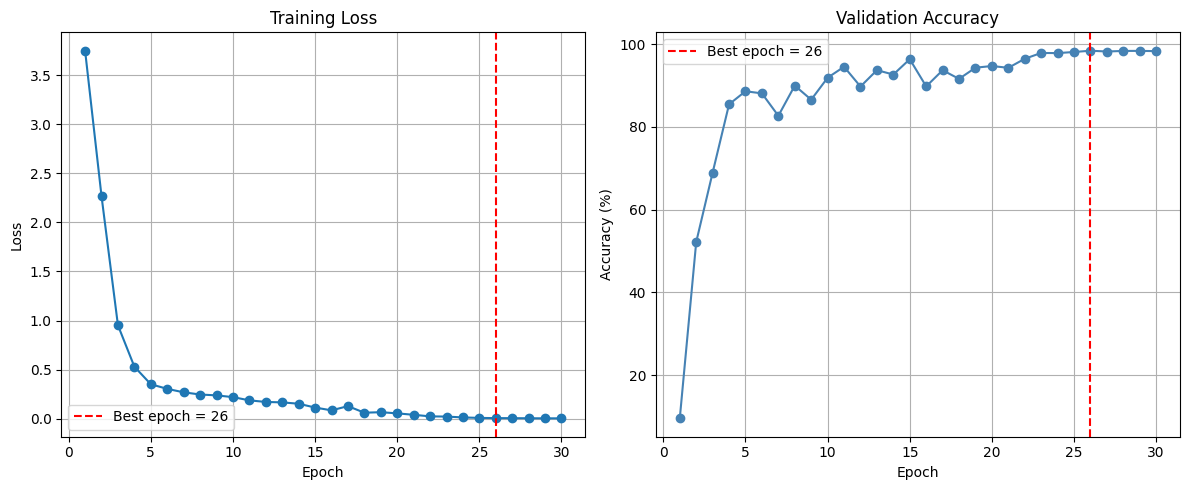

In [51]:
# ==========================================
# Training Curves — with vertical line at best epoch
# ==========================================
epochs = range(1, len(train_losses) + 1)
best_ep = es_tracker.best_epoch + 1   # human-friendly 1-based

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs, train_losses, marker='o')
axes[0].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch = {best_ep}')
axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True); axes[0].legend()

axes[1].plot(epochs, val_accuracies, marker='o', color='steelblue')
axes[1].axvline(best_ep, color='red', linestyle='--', label=f'Best epoch = {best_ep}')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True); axes[1].legend()

plt.tight_layout()
plt.show()

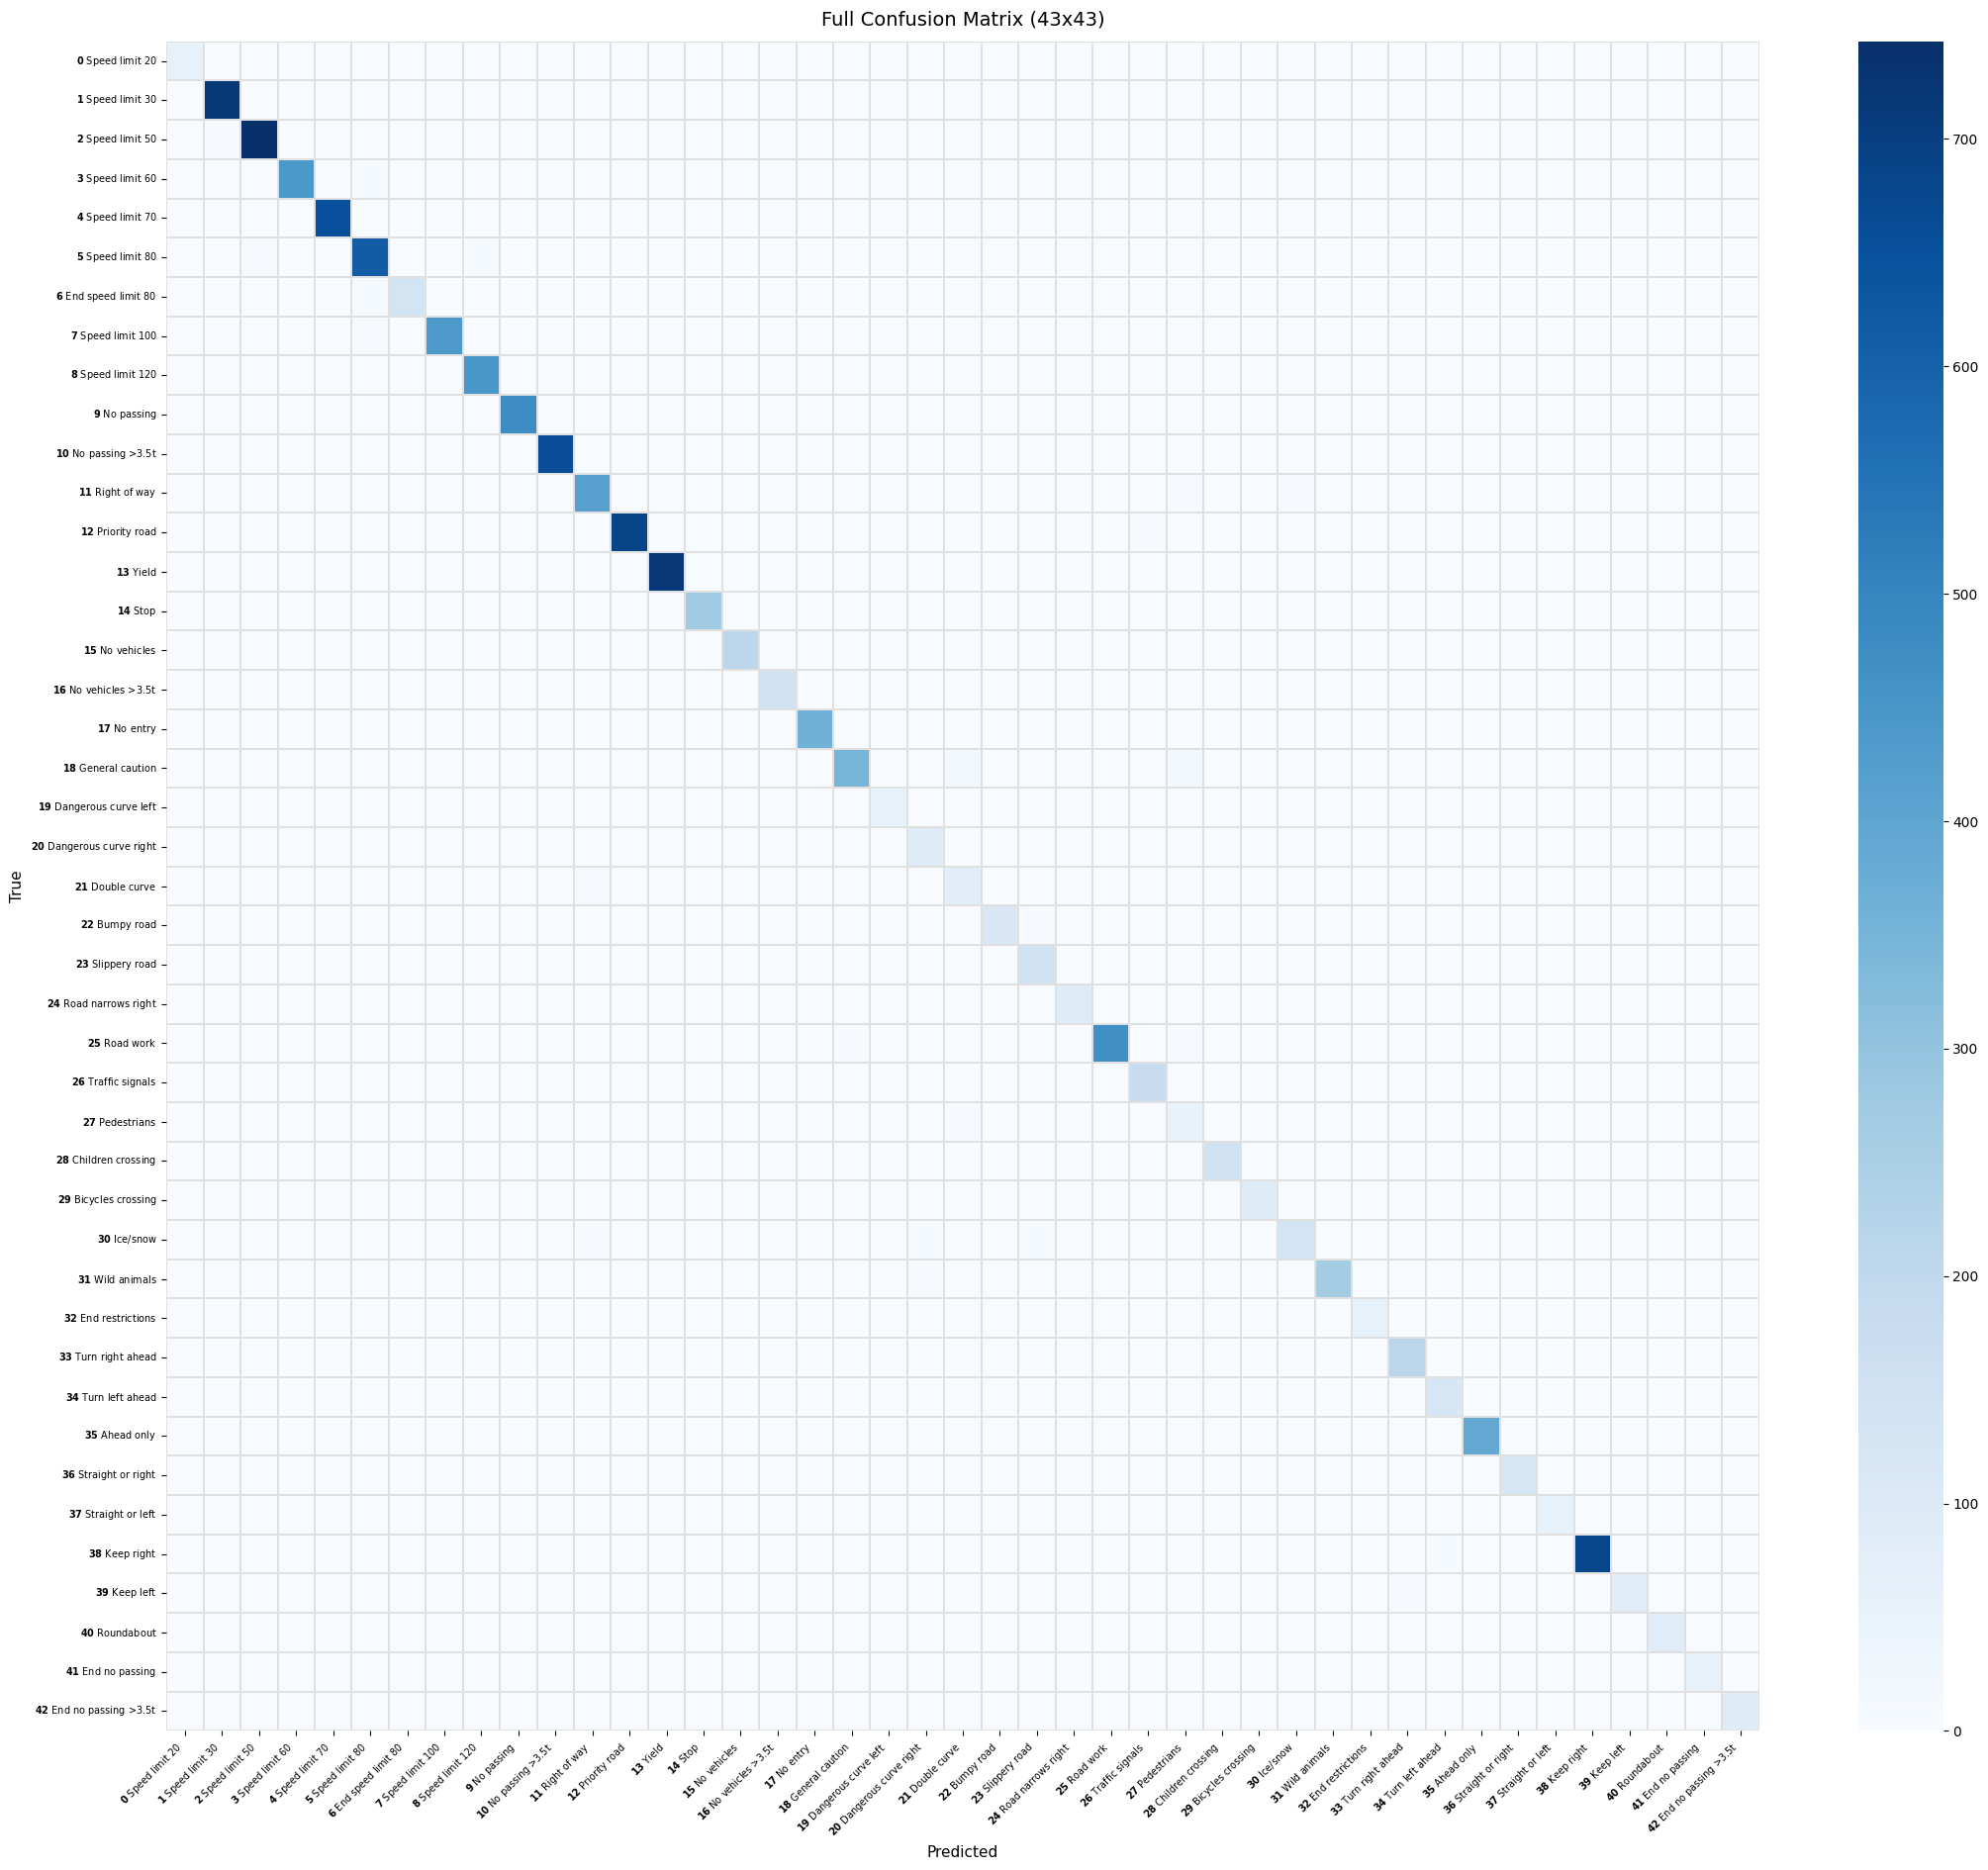

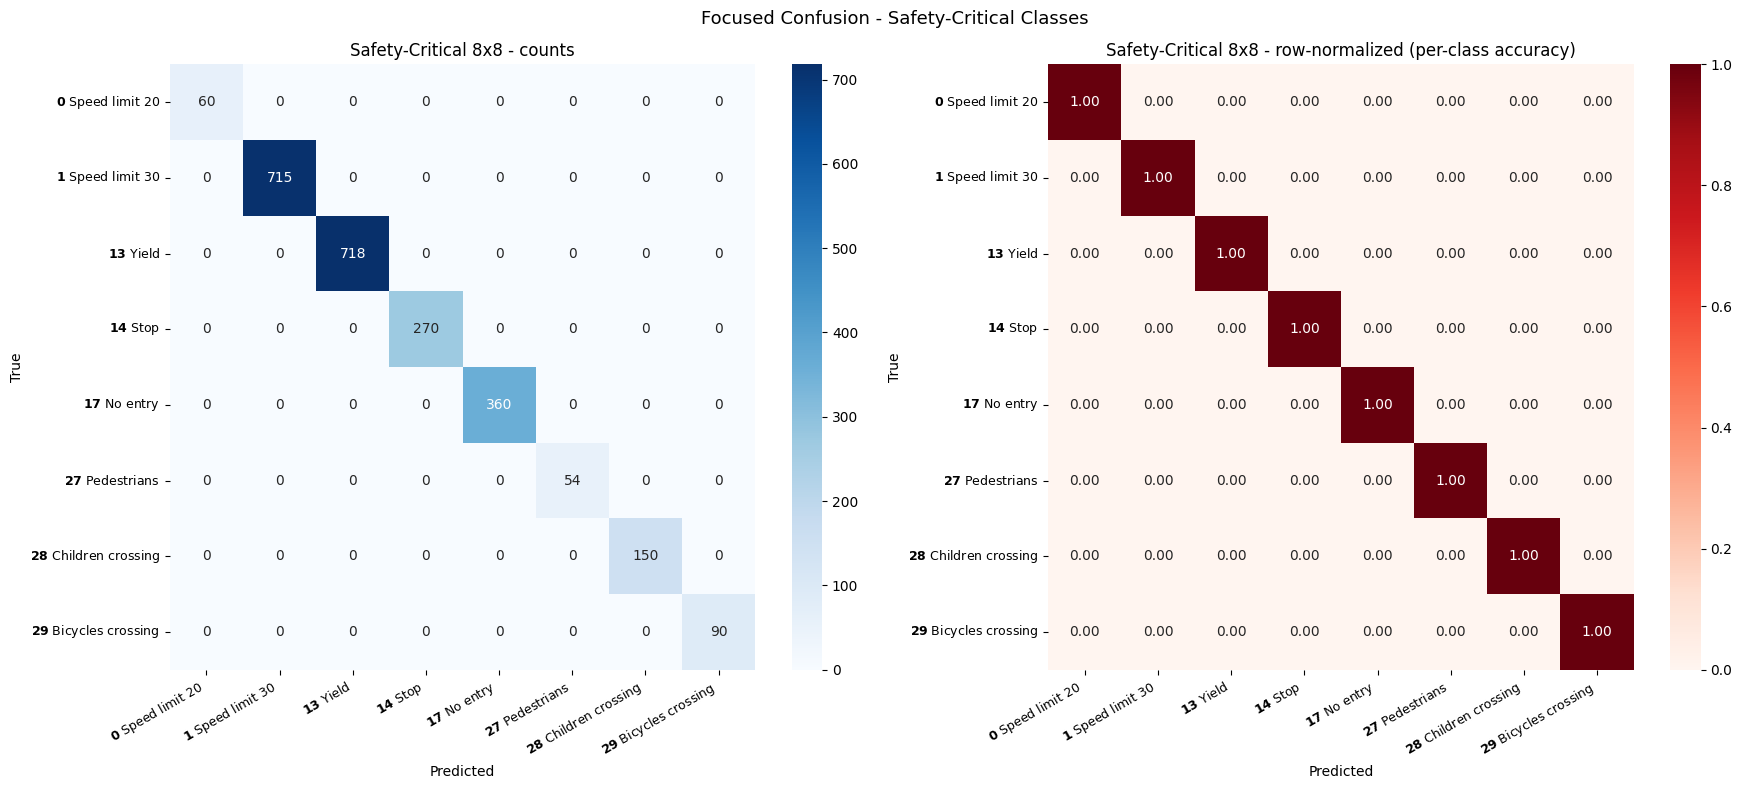


Safety-critical recall (diagonal of normalized 8x8):
   0 Speed limit 20            (moderate): 100.00%
   1 Speed limit 30            (moderate): 100.00%
  13 Yield                     (dangerous): 100.00%  <- DANGEROUS
  14 Stop                      (fatal): 100.00%  <- FATAL
  17 No entry                  (fatal): 100.00%  <- FATAL
  27 Pedestrians               (dangerous): 100.00%  <- DANGEROUS
  28 Children crossing         (dangerous): 100.00%  <- DANGEROUS
  29 Bicycles crossing         (dangerous): 100.00%  <- DANGEROUS


In [52]:
# ==========================================
# Confusion Matrix - full 43x43 + focused 8x8 safety-critical subset
# (Critical rule: 43x43 is hard to read, always show focused subset alongside)
# ==========================================

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device); labels = labels.to(device)
        preds = model(images).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

# ── Full 43x43 ─────────────────────────────────────────────────
labels_bold = [r'$\bf{' + str(i) + r'}$ ' + classes[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(22, 19))
sns.heatmap(
    cm, cmap='Blues', ax=ax,
    xticklabels=labels_bold, yticklabels=labels_bold,
    linewidths=0.3, linecolor='#e0e0e0'
)
ax.set_xticklabels(labels_bold, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(labels_bold, rotation=0, fontsize=7)
ax.set_title('Full Confusion Matrix (43x43)', fontsize=14, pad=12)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('True', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_full_43.png'), dpi=120)
plt.show()


# Prioritize by severity: all fatal + all dangerous + 2 most-critical moderate
# Result: 2 fatal + 4 dangerous + 2 moderate = 8 classes
critical_ids = sorted(set(
    SAFETY_CLASSES['fatal']           # [14, 17] - Stop, No entry
    + SAFETY_CLASSES['dangerous']     # [13, 27, 28, 29] - Yield, Pedestrians, Children, Bicycles
    + SAFETY_CLASSES['moderate'][:2]  # [0, 1] - Speed 20, Speed 30
))

cm_8 = cm[np.ix_(critical_ids, critical_ids)]
labels_8 = [r'$\bf{' + str(i) + r'}$ ' + classes[i] for i in critical_ids]

# Two views: counts and row-normalized (per-class accuracy)
row_sums = cm_8.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_8_norm = cm_8 / row_sums

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(
    cm_8, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_8, yticklabels=labels_8,
    cbar=True, ax=axes[0]
)
axes[0].set_title('Safety-Critical 8x8 - counts', fontsize=12)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_xticklabels(labels_8, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(labels_8, rotation=0, fontsize=9)

sns.heatmap(
    cm_8_norm, annot=True, fmt='.2f', cmap='Reds',
    xticklabels=labels_8, yticklabels=labels_8,
    vmin=0, vmax=1, cbar=True, ax=axes[1]
)
axes[1].set_title('Safety-Critical 8x8 - row-normalized (per-class accuracy)', fontsize=12)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_xticklabels(labels_8, rotation=30, ha='right', fontsize=9)
axes[1].set_yticklabels(labels_8, rotation=0, fontsize=9)

plt.suptitle('Focused Confusion - Safety-Critical Classes', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'confusion_safety_8x8.png'), dpi=120)
plt.show()

# Quick safety read-out
print('\nSafety-critical recall (diagonal of normalized 8x8):')
for k, cid in enumerate(critical_ids):
    grp = next((g for g, ids in SAFETY_CLASSES.items()
                if g != 'minor' and cid in ids), 'minor')
    flag = '  <- FATAL'     if grp == 'fatal' \
      else '  <- DANGEROUS' if grp == 'dangerous' \
      else ''
    print(f'  {cid:2d} {classes[cid]:25s} ({grp}): {cm_8_norm[k, k]*100:5.2f}%{flag}')

In [53]:
# ==========================================
# WSCER — Weighted Safety-Critical Error Rate
# Define once here, used in every evaluation
# ==========================================

def compute_wscer(true_labels, pred_labels, safety_classes, safety_weights, num_classes=43):
    """
    Weighted Safety-Critical Error Rate.

    For each class, counts misclassifications weighted by safety severity.
    A Stop sign misclassified counts 4x more than a minor sign misclassified.

    Args:
        true_labels  : list or array of ground truth class indices
        pred_labels  : list or array of predicted class indices
        safety_classes: dict mapping group name -> list of class IDs
        safety_weights: dict mapping group name -> integer weight
        num_classes  : total number of classes (43 for GTSRB)

    Returns:
        wscer        : float, weighted error rate in [0, 1]
        breakdown    : dict with per-group weighted error counts
    """
    true_labels = np.array(true_labels)
    pred_labels = np.array(pred_labels)

    # Build per-class weight vector
    class_weight = np.ones(num_classes, dtype=float)
    for group_name, cls_list in safety_classes.items():
        w = safety_weights[group_name]
        for cls_id in cls_list:
            class_weight[cls_id] = w

    # Weighted error: for each sample, if wrong → add safety_weight[true_class]
    is_wrong = (true_labels != pred_labels).astype(float)
    sample_weights = class_weight[true_labels]          # weight per sample

    weighted_errors = (is_wrong * sample_weights).sum()
    weighted_total  = sample_weights.sum()              # max possible weighted error

    wscer = weighted_errors / weighted_total

    # Per-group breakdown for reporting
    breakdown = {}
    for group_name, cls_list in safety_classes.items():
        mask = np.isin(true_labels, cls_list)
        if mask.sum() == 0:
            breakdown[group_name] = {'errors': 0, 'total': 0, 'error_rate': 0.0,
                                     'weight': safety_weights[group_name]}
            continue
        group_errors = is_wrong[mask].sum()
        group_total  = mask.sum()
        breakdown[group_name] = {
            'errors':     int(group_errors),
            'total':      int(group_total),
            'error_rate': group_errors / group_total,
            'weight':     safety_weights[group_name]
        }

    return wscer, breakdown

def print_wscer(wscer, breakdown, model_name="Model"):
    """Pretty-print WSCER result with per-group breakdown."""
    print(f"\n{'='*52}")
    print(f"  WSCER — {model_name}")
    print(f"{'='*52}")
    print(f"  Overall WSCER: {wscer:.4f}  ({wscer*100:.2f}%)")
    print(f"  (lower is safer — 0.0 = perfect, 1.0 = worst)")
    print(f"{'─'*52}")
    print(f"  {'Group':<12} {'Weight':>6}  {'Errors':>7}  {'Total':>7}  {'Error%':>8}")
    print(f"{'─'*52}")
    for group, stats in breakdown.items():
        print(f"  {group:<12} {stats['weight']:>6}  "
              f"{stats['errors']:>7}  {stats['total']:>7}  "
              f"{stats['error_rate']*100:>7.2f}%")
    print(f"{'='*52}\n")

# ── Compute WSCER for the baseline model ────────────────────────────
# all_labels and all_preds must exist (from confusion matrix cell 21)
baseline_wscer, baseline_breakdown = compute_wscer(
    all_labels, all_preds,
    SAFETY_CLASSES, SAFETY_WEIGHTS
)
print_wscer(baseline_wscer, baseline_breakdown, model_name="Baseline ResNet-18")

# Save for comparison table
wscer_results = {'baseline': baseline_wscer}
print(f"Saved baseline WSCER: {baseline_wscer:.4f}")
# ==========================================
# Severity-Weighted F1 + Fatal Recall
# (used for early stopping in safety-aware training)
# ==========================================
from sklearn.metrics import f1_score, recall_score

# Build severity weight per class id (default = 1 = minor)
SEVERITY_PER_CLASS = np.ones(NUM_CLASSES, dtype=float)
for grp, ids in SAFETY_CLASSES.items():
    if grp == 'minor':
        continue
    w = SAFETY_WEIGHTS[grp]
    for cid in ids:
        SEVERITY_PER_CLASS[cid] = w

FATAL_CLASSES_IDS = SAFETY_CLASSES['fatal']    # [14, 17] - Stop, No entry
FATAL_RECALL_THRESHOLD = 0.99                  # red flag below this

def severity_weighted_f1(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    f1_per = f1_score(y_true, y_pred, average=None,
                       labels=list(range(NUM_CLASSES)), zero_division=0)
    return float(np.average(f1_per, weights=SEVERITY_PER_CLASS))

def fatal_recall(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = np.isin(y_true, FATAL_CLASSES_IDS)
    if mask.sum() == 0:
        return 1.0
    return float(recall_score(y_true[mask], y_pred[mask], average='macro',
                              labels=FATAL_CLASSES_IDS, zero_division=0))

# Compute on baseline so we have a reference number
baseline_swf1   = severity_weighted_f1(all_labels, all_preds)
baseline_fatalR = fatal_recall(all_labels, all_preds)
print(f'Baseline Severity-Weighted F1: {baseline_swf1:.4f}')
print(f'Baseline Fatal Recall:         {baseline_fatalR:.4f}'
      + ('  [RED FLAG]' if baseline_fatalR < FATAL_RECALL_THRESHOLD else ''))


  WSCER — Baseline ResNet-18
  Overall WSCER: 0.0130  (1.30%)
  (lower is safer — 0.0 = perfect, 1.0 = worst)
────────────────────────────────────────────────────
  Group        Weight   Errors    Total    Error%
────────────────────────────────────────────────────
  fatal             4        0      630     0.00%
  dangerous         3        8     1020     0.78%
  moderate          2       52     4170     1.25%
  minor             1      142     6810     2.09%

Saved baseline WSCER: 0.0130
Baseline Severity-Weighted F1: 0.9746
Baseline Fatal Recall:         1.0000


Worst confused pair: class 18 -> class 27 (19 mistakes)
Found 19 images  |  True: 'General caution'  ->  Pred: 'Pedestrians'


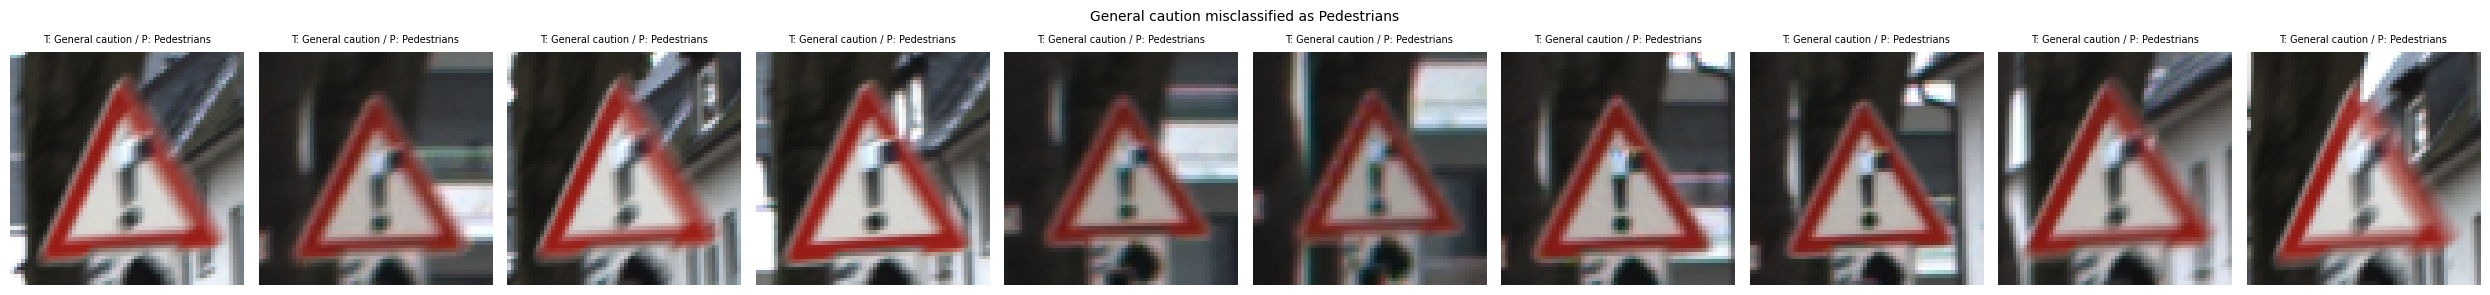

In [54]:
# ==========================================
# Show Confused Image Pairs
# ==========================================

def show_confused_images(true_class, pred_class, max_imgs=10):
    mean = np.array(MEAN)
    std  = np.array(STD)

    confused_idx = [
        i for i, (t, p) in enumerate(zip(all_labels, all_preds))
        if t == true_class and p == pred_class
    ]

    true_name = classes[true_class]
    pred_name = classes[pred_class]
    print(f"Found {len(confused_idx)} images  |  True: '{true_name}'  ->  Pred: '{pred_name}'")

    if not confused_idx:
        print("No confused images found for this pair.")
        return

    n = min(max_imgs, len(confused_idx))
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, confused_idx[:max_imgs]):
        img, _ = testset[idx]
        img = img.permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title("T: " + true_name + " / P: " + pred_name, fontsize=7)
        ax.axis("off")

    plt.suptitle(f"{true_name} misclassified as {pred_name}", fontsize=10)
    plt.tight_layout()
    plt.show()

# Auto-find the worst confused pair from the confusion matrix
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
worst_true, worst_pred = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
n_mistakes = cm_no_diag[worst_true, worst_pred]
print(f"Worst confused pair: class {worst_true} -> class {worst_pred} ({n_mistakes} mistakes)")

show_confused_images(true_class=worst_true, pred_class=worst_pred)

# To inspect any specific pair, call directly:
# show_confused_images(true_class=5, pred_class=3)  # Speed 80 -> Speed 60


Per-class accuracy:

 0 Speed limit 20           : 100.00%
 1 Speed limit 30           : 99.31%
 2 Speed limit 50           : 99.07%
 3 Speed limit 60           : 98.44%
 4 Speed limit 70           : 98.94%
 5 Speed limit 80           : 97.94%
 6 End speed limit 80       : 90.67%
 7 Speed limit 100          : 97.56%
 8 Speed limit 120          : 99.56%
 9 No passing               : 99.58%
10 No passing >3.5t         : 99.85%
11 Right of way             : 98.33%
12 Priority road            : 99.28%
13 Yield                    : 99.72%
14 Stop                     : 100.00%
15 No vehicles              : 99.52%
16 No vehicles >3.5t        : 100.00%
17 No entry                 : 100.00%
18 General caution          : 89.74%
19 Dangerous curve left     : 100.00%
20 Dangerous curve right    : 100.00%
21 Double curve             : 88.89%
22 Bumpy road               : 95.00%
23 Slippery road            : 100.00%
24 Road narrows right       : 100.00%
25 Road work                : 97.92%
26 Traff

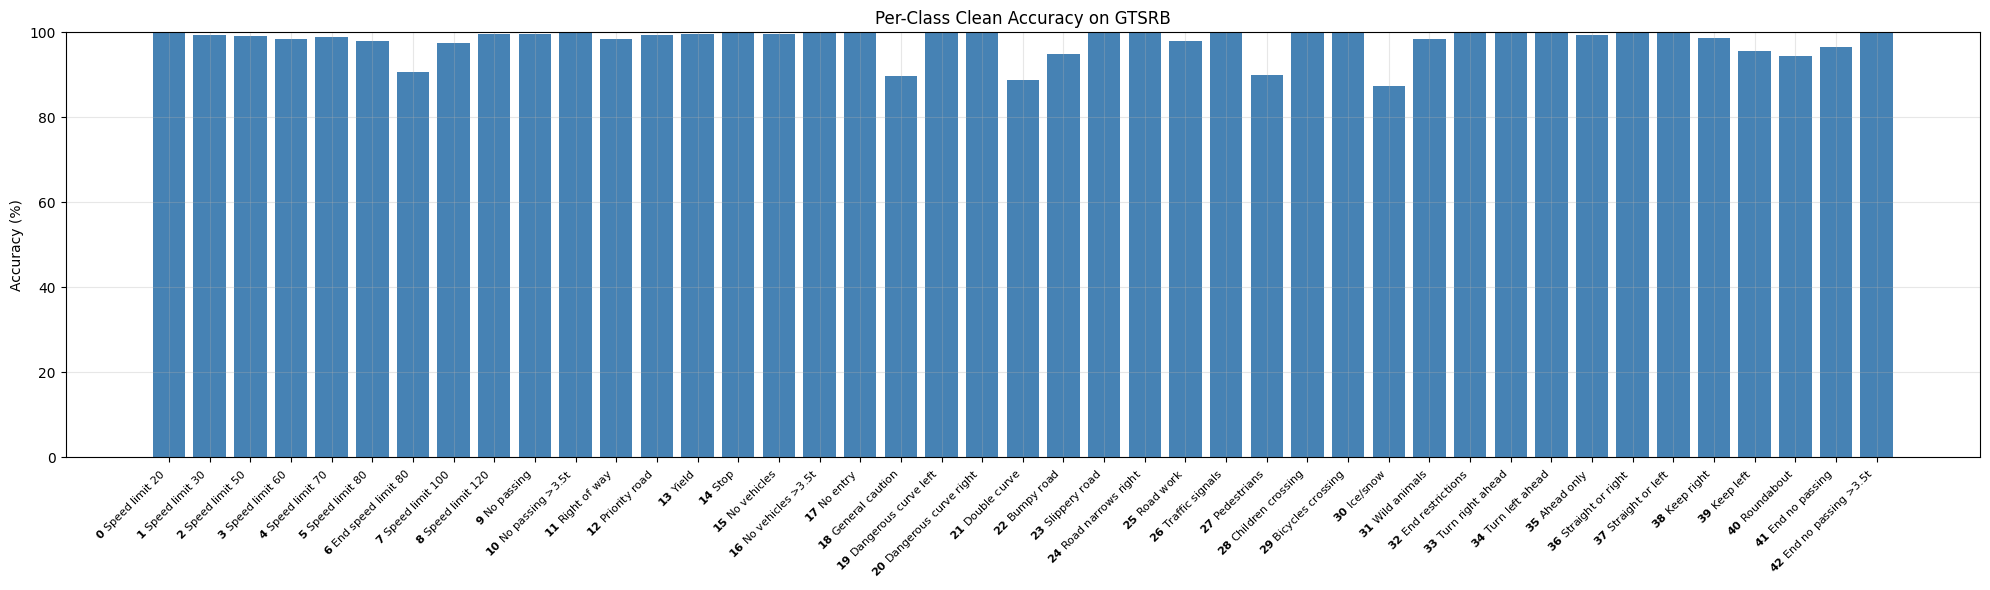


Worst 5 Classes:

Class 30 (Ice/snow): 87.33%
Class 21 (Double curve): 88.89%
Class 18 (General caution): 89.74%
Class 27 (Pedestrians): 90.00%
Class  6 (End speed limit 80): 90.67%

Best 5 Classes:
Class 33 (Turn right ahead): 100.00%
Class 34 (Turn left ahead): 100.00%
Class 36 (Straight or right): 100.00%
Class 37 (Straight or left): 100.00%
Class 42 (End no passing >3.5t): 100.00%


In [55]:
# ==========================================
# Per-Class Accuracy + Visualization
# ==========================================

# Accumulators for correct predictions and total samples per class
correct_per_class = [0] * NUM_CLASSES
total_per_class   = [0] * NUM_CLASSES

# ── Inference loop ────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():  # Disable gradient tracking — evaluation only
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)  # Get the class index with highest logit

        # Update per-class counters for each sample in the batch
        for y_true, y_pred in zip(labels, preds):
            total_per_class[y_true.item()] += 1
            if y_true == y_pred:
                correct_per_class[y_true.item()] += 1

# ── Compute and print per-class accuracy ─────────────────────────────────────
per_class_acc = []
print('\nPer-class accuracy:\n')
for i in range(NUM_CLASSES):
    acc = 100 * correct_per_class[i] / total_per_class[i]
    per_class_acc.append(acc)
    print(f'{i:2d} {classes[i]:25s}: {acc:.2f}%')

# ── Build bar chart ───────────────────────────────────────────────────────────

# Format x-axis labels: bold class index + class name (LaTeX bold syntax for matplotlib)
labels_bold = [r'$\bf{' + str(i) + r'}$ ' + classes[i] for i in range(NUM_CLASSES)]

# Highlight underperforming classes in red (< 80% accuracy), others in steelblue
colors = ['red' if acc < 80 else 'steelblue' for acc in per_class_acc]

fig, ax = plt.subplots(figsize=(20, 6))
ax.bar(range(NUM_CLASSES), per_class_acc, color=colors)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(labels_bold, rotation=45, ha='right', fontsize=8)
ax.set_title('Per-Class Clean Accuracy on GTSRB')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Best / Worst class summary ────────────────────────────────────────────────

# Sort all classes by accuracy ascending so slicing gives worst ([:5]) and best ([-5:])
sorted_classes = sorted(
    [(i, per_class_acc[i]) for i in range(NUM_CLASSES)],
    key=lambda x: x[1]
)

# Worst 5 — most likely candidates for weighted loss or extra augmentation
print('\nWorst 5 Classes:\n')
for cls, acc in sorted_classes[:5]:
    print(f'Class {cls:2d} ({classes[cls]}): {acc:.2f}%')

# Best 5 — classes the model has learned most reliably
print('\nBest 5 Classes:')
for cls, acc in sorted_classes[-5:]:
    print(f'Class {cls:2d} ({classes[cls]}): {acc:.2f}%')

In [56]:
# ==========================================
# Save Per-Class Accuracy to CSV
# ==========================================

results_df = pd.DataFrame({
    "class_id": list(range(NUM_CLASSES)),
    "class_name": classes,
    "accuracy": per_class_acc
})

csv_path = os.path.join(BASE_DIR, "per_class_accuracy.csv")
results_df.to_csv(csv_path, index=False)

print(f"Per-class accuracy saved -> {csv_path}")
print(results_df.sort_values("accuracy").head(5).to_string(index=False))

Per-class accuracy saved -> /kaggle/working/led_project/per_class_accuracy.csv
 class_id         class_name  accuracy
       30           Ice/snow 87.333333
       21       Double curve 88.888889
       18    General caution 89.743590
       27        Pedestrians 90.000000
        6 End speed limit 80 90.666667


## MobileNetV2 Baseline and Class Imbalance Analysis
Train a second architecture and test Contribution 1: are rare classes more vulnerable? (In this run: no significant correlation, see Figure 4.)

In [57]:
# ==========================================
# MobileNetV2 (Model B)
# ==========================================

model_b = models.mobilenet_v2(weights=None, num_classes=NUM_CLASSES)
model_b = model_b.to(device)

criterion_b = nn.CrossEntropyLoss(weight=_weights)  # same inverse-frequency weights as ResNet-18
optimizer_b = torch.optim.SGD(model_b.parameters(), lr=LR,
                              momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=EPOCHS)

print('MobileNetV2 ready, params:',
      sum(p.numel() for p in model_b.parameters()) / 1e6, 'M')

MobileNetV2 ready, params: 2.278955 M


In [58]:
# =================================================================
# Train MobileNetV2 — load from checkpoint OR train from scratch
# =================================================================
import json as _json  # Aliased to avoid conflicts with any user-defined 'json' variable

# Attempt to restore saved weights + training history from disk.
# If successful, the entire training block below is skipped.
loaded, hist = try_load_checkpoint(model_b, 'mobilenetv2_gtsrb.pth', 'mobilenetv2_gtsrb_history.json')

if loaded:
    # ── Checkpoint found: reconstruct history so downstream cells work ──
    train_losses_b   = hist['train_losses']
    val_accuracies_b = hist['val_accuracies']

    # Reconstruct a minimal tracker object from saved metadata using an
    # anonymous class — avoids re-instantiating EarlyStoppingTracker
    es_b = type('obj', (), {
        'best_epoch': hist.get('best_epoch', len(val_accuracies_b)) - 1,  # 0-based
        'best_acc':   hist.get('best_acc',   val_accuracies_b[-1]),
    })()
    print(f"Best epoch: {es_b.best_epoch + 1}, best acc: {es_b.best_acc:.2f}%")

else:
    # ── No checkpoint: train from scratch ────────────────────────────────
    train_losses_b   = []   # Average training loss per epoch
    val_accuracies_b = []   # Test-set accuracy (%) per epoch
    es_b             = EarlyStoppingTracker(patience=5)
    best_state_b     = None  # Will hold a CPU copy of the best model weights

    n_batches = len(trainloader)

    print('=' * 60)
    print(f' MOBILENETV2  |  {EPOCHS} epochs  |  {n_batches} batches/epoch')
    print('=' * 60)

    t_total = time.time()  # Wall-clock timer for total training duration

    for epoch in range(EPOCHS):
        t_ep = time.time()   # Per-epoch timer
        model_b.train()      # Enable dropout / batch-norm training behaviour
        total_loss = 0

        # ── Training loop ─────────────────────────────────────────────
        for b_idx, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)

            optimizer_b.zero_grad()                          # Clear gradients from previous batch
            loss = criterion_b(model_b(images), labels)      # Forward pass + compute loss
            loss.backward()                                   # Backprop: compute gradients
            optimizer_b.step()                               # Update weights
            total_loss += loss.item()

            # Print progress ~5 times per epoch (every 20% of batches)
            if (b_idx + 1) % max(1, n_batches // 5) == 0:
                print(f'    [Epoch {epoch+1:02d}] batch {b_idx+1:4d}/{n_batches}  '
                      f'running_loss={total_loss/(b_idx+1):.3f}')

        # Advance the LR scheduler at the end of each epoch (CosineAnnealing)
        scheduler_b.step()

        # ── Validation loop ───────────────────────────────────────────
        model_b.eval()  # Disable dropout / use running stats for batch-norm
        correct = total = 0
        with torch.no_grad():  # No gradients needed for evaluation — saves memory
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                preds = model_b(images).argmax(1)              # Predicted class indices
                correct += (preds == labels).sum().item()      # Count correct predictions
                total   += labels.size(0)

        # Compute and record epoch-level metrics
        epoch_loss = total_loss / n_batches
        epoch_acc  = 100 * correct / total
        train_losses_b.append(epoch_loss)
        val_accuracies_b.append(epoch_acc)

        # Notify the early stopping tracker; returns 'IMPROVED' or 'NO_IMPROVE'
        flag = es_b.step(epoch_acc, epoch)

        # If this is the best epoch so far, snapshot weights to CPU memory.
        # Storing on CPU avoids doubling GPU memory usage during training.
        if flag == 'IMPROVED':
            best_state_b = {k: v.clone().cpu() for k, v in model_b.state_dict().items()}

        # Gather logging metadata for this epoch
        cur_lr  = optimizer_b.param_groups[0]['lr']
        ep_time = time.time() - t_ep
        tag     = ' <- new best' if flag == 'IMPROVED' else ''

        # Log every 5th epoch AND any epoch that sets a new best accuracy
        if (epoch + 1) % 5 == 0 or flag == 'IMPROVED':
            print(f'  Epoch {epoch+1:02d}/{EPOCHS} | loss={epoch_loss:.3f} | '
                  f'acc={epoch_acc:.2f}% | lr={cur_lr:.4f} | {ep_time:.1f}s' + tag)

    # ── Post-training: restore best checkpoint ────────────────────────
    # The final epoch is rarely the best one — restoring best_state_b ensures
    # that all downstream evaluation and saving uses the peak-accuracy weights
    if best_state_b is not None:
        model_b.load_state_dict(best_state_b)
        print(f"Restored best weights from epoch {es_b.best_epoch + 1}")

    total_time = time.time() - t_total
    print('=' * 60)
    print(f' DONE  |  total {total_time/60:.1f} min  |  best epoch '
          f'{es_b.best_epoch + 1}  |  best acc {es_b.best_acc:.2f}%')
    print('=' * 60)

    # Persist model weights and training metrics to disk
    # Only saved when actually trained — not when loaded from checkpoint,
    # to avoid overwriting a valid checkpoint with identical data
    torch.save(model_b.state_dict(), os.path.join(BASE_DIR, 'mobilenetv2_gtsrb.pth'))

    mob_metrics = {
        "train_losses":   train_losses_b,
        "val_accuracies": val_accuracies_b,
        "epochs":         EPOCHS,
        "img_size":       IMG_SIZE,
        "final_acc":      val_accuracies_b[-1],   # Accuracy at last epoch (not necessarily best)
        "best_epoch":     es_b.best_epoch + 1,    # 1-based for human readability in JSON
        "best_acc":       es_b.best_acc,
    }
    with open(os.path.join(BASE_DIR, 'mobilenetv2_gtsrb_history.json'), 'w') as f:
        _json.dump(mob_metrics, f, indent=2)

    print(f"MobileNetV2 saved   -> {BASE_DIR}/mobilenetv2_gtsrb.pth")
    print(f"MobileNetV2 metrics -> {BASE_DIR}/mobilenetv2_gtsrb_history.json")

# ── Cross-model best epoch registry ──────────────────────────────────────────
# Initialise the dict on first use; subsequent models append their own entry.
# Works for both loaded and freshly trained runs.
if 'model_best_epochs' not in dir():
    model_best_epochs = {}
model_best_epochs['MobileNetV2'] = es_b.best_epoch + 1

Loaded mobilenetv2_gtsrb.pth (+ mobilenetv2_gtsrb_history.json)
Best epoch: 28, best acc: 96.20%


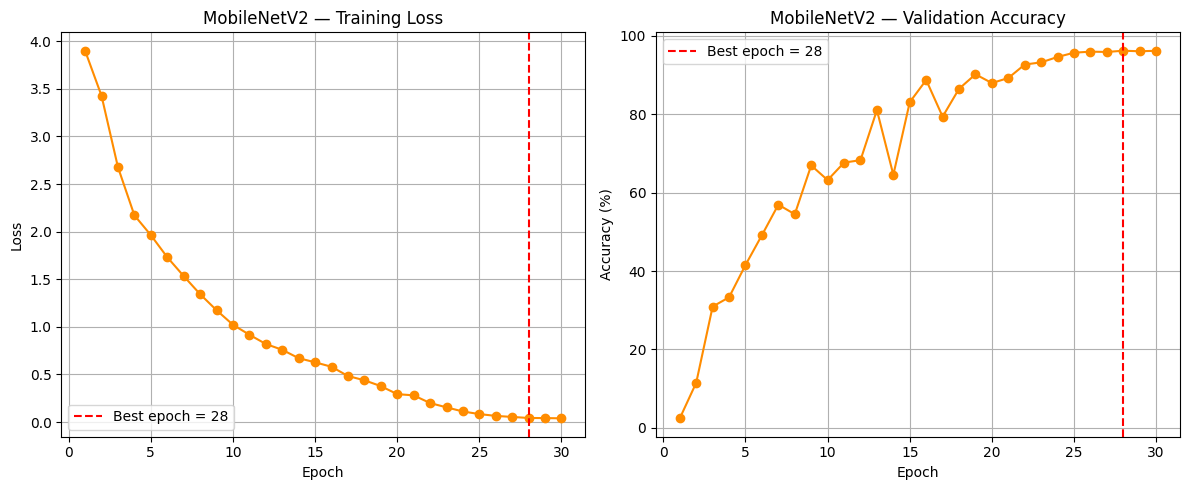

In [59]:
# ===============================================================
# MobileNetV2 Training Curves — with vertical line at best epoch
# ===============================================================

epochs_b = range(1, len(train_losses_b) + 1)
best_ep_b = es_b.best_epoch + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_b, train_losses_b, marker='o', color='darkorange')
axes[0].axvline(best_ep_b, color='red', linestyle='--', label=f'Best epoch = {best_ep_b}')
axes[0].set_title('MobileNetV2 — Training Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True); axes[0].legend()

axes[1].plot(epochs_b, val_accuracies_b, marker='o', color='darkorange')
axes[1].axvline(best_ep_b, color='red', linestyle='--', label=f'Best epoch = {best_ep_b}')
axes[1].set_title('MobileNetV2 — Validation Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'mobilenetv2_training_curves.png'), dpi=120)
plt.show()

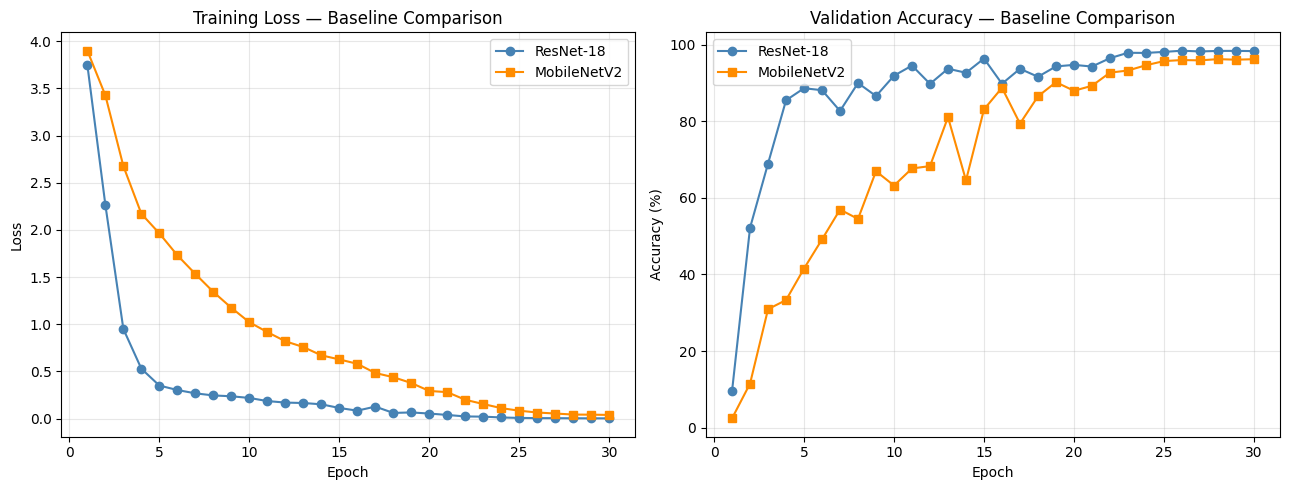

In [60]:
# =============================================
# Combined comparison: ResNet-18 vs MobileNetV2
# =============================================

epochs_r = range(1, len(train_losses) + 1)
epochs_b = range(1, len(train_losses_b) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_r, train_losses,   marker='o', label='ResNet-18',   color='steelblue')
axes[0].plot(epochs_b, train_losses_b, marker='s', label='MobileNetV2', color='darkorange')
axes[0].set_title('Training Loss — Baseline Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_r, val_accuracies,   marker='o', label='ResNet-18',   color='steelblue')
axes[1].plot(epochs_b, val_accuracies_b, marker='s', label='MobileNetV2', color='darkorange')
axes[1].set_title('Validation Accuracy — Baseline Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'baselines_comparison_curves.png'), dpi=120)
plt.show()

# Attacks Implementation


## FGSM Attack Implementation

In [61]:
# ==========================================
# FGSM Attack (Goodfellow et al., 2015)
# Epsilon is defined in pixel space [0, 1], matching the
# original paper and torchattacks.
# ==========================================

def fgsm_attack(model, images, labels, epsilon):
    """
    Inputs and outputs live in normalized space (dataloader format).
    Internally: denormalize -> attack in pixel space -> clamp -> renormalize.
    """
    mean = torch.tensor(MEAN, device=images.device).view(1, 3, 1, 1)
    std  = torch.tensor(STD,  device=images.device).view(1, 3, 1, 1)

    # Denormalize to pixel space [0, 1]
    x_pix = (images * std + mean).clone().detach().requires_grad_(True)

    # Model expects normalized input
    outputs = model((x_pix - mean) / std)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()

    # Perturb in pixel space and keep pixels valid
    adv_pix = x_pix + epsilon * x_pix.grad.sign()
    adv_pix = torch.clamp(adv_pix, 0.0, 1.0)

    # Renormalize for the downstream pipeline
    return ((adv_pix - mean) / std).detach()

print("FGSM attack defined (pixel-space).")

FGSM attack defined (pixel-space).


In [62]:
# ==========================================
# Verify FGSM against torchattacks
# Both implementations attack in pixel space.
# `set_normalization_used` tells torchattacks our inputs are normalized.
# ==========================================

model.eval()
images_batch, labels_batch = next(iter(testloader))
images_batch, labels_batch = images_batch.to(device), labels_batch.to(device)

eps_verify = 8/255

our_adv = fgsm_attack(model, images_batch, labels_batch, eps_verify)

lib_attack = torchattacks.FGSM(model, eps=eps_verify)
lib_attack.set_normalization_used(mean=MEAN, std=STD)
lib_adv = lib_attack(images_batch, labels_batch)

with torch.no_grad():
    our_acc = 100 * (model(our_adv).argmax(1) == labels_batch).float().mean().item()
    lib_acc = 100 * (model(lib_adv).argmax(1) == labels_batch).float().mean().item()

max_diff  = (our_adv - lib_adv).abs().max().item()
mean_diff = (our_adv - lib_adv).abs().mean().item()

print(f"Our FGSM accuracy:     {our_acc:.2f}%")
print(f"torchattacks accuracy: {lib_acc:.2f}%")
print(f"Max pixel difference:  {max_diff:.6f}")
print(f"Mean pixel difference: {mean_diff:.6f}")

if max_diff < 1e-4:
    print("\nFGSM implementation verified.")
else:
    print("\nMismatch — check implementation.")

Our FGSM accuracy:     57.81%
torchattacks accuracy: 57.81%
Max pixel difference:  0.000000
Mean pixel difference: 0.000000

FGSM implementation verified.


In [63]:
# ==========================================
# FGSM sweep across epsilon values
# Data for Figure 5: FGSM accuracy curve
# ==========================================

model.eval()
fgsm_accuracies = []

print(f"{'Epsilon':>10s}  {'Accuracy':>10s}  {'ASR':>10s}")
print("-" * 36)

for eps, label in zip(EPSILONS, EPSILON_LABELS):
    correct, total = 0, 0

    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        if eps == 0:
            adv_images = images
        else:
            adv_images = fgsm_attack(model, images, labels, eps)

        with torch.no_grad():
            preds = model(adv_images).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    acc = 100 * correct / total
    fgsm_accuracies.append(acc)
    print(f"ε={label:>8s}  →  {acc:6.2f}%  {100-acc:8.2f}%")

print(f"\nFGSM sweep complete.")

   Epsilon    Accuracy         ASR
------------------------------------
ε=       0  →   98.40%      1.60%
ε=   2/255  →   80.81%     19.19%
ε=   4/255  →   65.60%     34.40%
ε=   8/255  →   46.71%     53.29%
ε=  16/255  →   30.12%     69.88%
ε=  32/255  →   17.38%     82.62%

FGSM sweep complete.


In [64]:
# ==========================================
#  Per-class robust accuracy under FGSM
# ==========================================

eps_c1 = 8/255  # standard benchmark epsilon

correct_per_class = [0] * NUM_CLASSES
total_per_class   = [0] * NUM_CLASSES

model.eval()

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    adv_images = fgsm_attack(model, images, labels, eps_c1)

    with torch.no_grad():
        preds = model(adv_images).argmax(1)

    for y_true, y_pred in zip(labels.cpu(), preds.cpu()):
        total_per_class[y_true.item()] += 1
        if y_true == y_pred:
            correct_per_class[y_true.item()] += 1

per_class_robust_acc_fgsm = [
    100 * correct_per_class[i] / total_per_class[i]
    if total_per_class[i] > 0 else 0.0
    for i in range(NUM_CLASSES)
]

print(f"Per-class robust accuracy under FGSM (ε={eps_c1:.4f}):\n")
for i, acc in enumerate(per_class_robust_acc_fgsm):
    flag = " ← FATAL"   if i in SAFETY_CLASSES['fatal']     else \
           " ← dangerous" if i in SAFETY_CLASSES['dangerous'] else ""
    print(f"{i:2d} {classes[i]:30s}: {acc:6.2f}%{flag}")

Per-class robust accuracy under FGSM (ε=0.0314):

 0 Speed limit 20                :  20.00%
 1 Speed limit 30                :  53.61%
 2 Speed limit 50                :  31.47%
 3 Speed limit 60                :   8.44%
 4 Speed limit 70                :  21.36%
 5 Speed limit 80                :  16.98%
 6 End speed limit 80            :  12.00%
 7 Speed limit 100               :   5.56%
 8 Speed limit 120               :  16.22%
 9 No passing                    :  53.96%
10 No passing >3.5t              :  42.73%
11 Right of way                  :  63.10%
12 Priority road                 :  70.29%
13 Yield                         :  76.67% ← dangerous
14 Stop                          :  72.96% ← FATAL
15 No vehicles                   :  30.48%
16 No vehicles >3.5t             :  58.67%
17 No entry                      :  88.33% ← FATAL
18 General caution               :  41.79%
19 Dangerous curve left          :  45.00%
20 Dangerous curve right         :  58.89%
21 Double curve    

Pearson r = 0.108   p = 0.4923


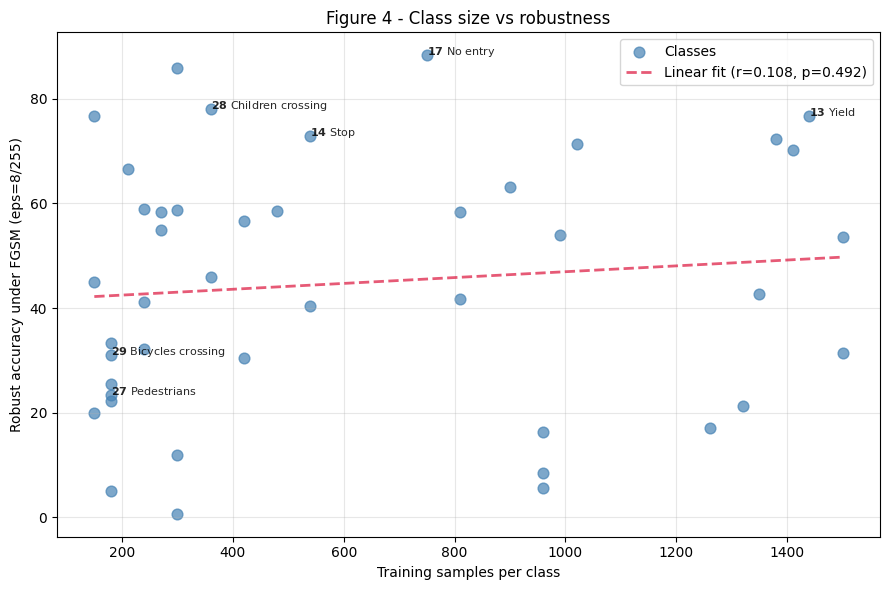

In [65]:
# ==========================================
# Contribution 1: Class size vs robust accuracy
# Figure 4
# ==========================================
from scipy.stats import pearsonr, linregress

samples_per_class = [_counts[i] for i in range(NUM_CLASSES)]
robust_acc        = per_class_robust_acc_fgsm

r, p = pearsonr(samples_per_class, robust_acc)
print(f'Pearson r = {r:.3f}   p = {p:.4f}')

# Linear regression fit for trend visualization
slope, intercept, _, _, _ = linregress(samples_per_class, robust_acc)
x_line = np.array([min(samples_per_class), max(samples_per_class)])
y_line = slope * x_line + intercept

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(samples_per_class, robust_acc, alpha=0.7, s=60, color='steelblue', label='Classes')
ax.plot(x_line, y_line, '--', color='crimson', alpha=0.7, linewidth=2,
        label=f'Linear fit (r={r:.3f}, p={p:.3f})')

for i, name in enumerate(classes):
    if i in SAFETY_CLASSES['fatal'] or i in SAFETY_CLASSES['dangerous']:
        ax.annotate(r'$\bf{' + str(i) + r'}$ ' + name,
                    (samples_per_class[i], robust_acc[i]),
                    fontsize=8, alpha=0.85)

ax.set_xlabel('Training samples per class')
ax.set_ylabel('Robust accuracy under FGSM (eps=8/255)')
ax.set_title('Figure 4 - Class size vs robustness')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig4_class_size_vs_robustness.png'), dpi=120)
plt.show()

## PGD Attack Implementation
Implement PGD-20 (Madry et al. 2018), verify against torchattacks, sweep over epsilons, and install Grad-CAM.

In [66]:
# Install Grad-CAM library (used by the Grad-CAM figures below)
%pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
print('grad-cam ready')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
grad-cam ready


In [67]:
# ==========================================
# PGD Attack (Madry et al., 2018)
# Both epsilon and alpha are in pixel-space units.
# Inner attack used in PGD-AT training: steps=7 random_start=True.
# Evaluation attack: steps=20.
# ==========================================

def pgd_attack(model, images, labels, epsilon, alpha=None, steps=20, random_start=True):
    """
    Inputs and outputs in normalized space.
    Internally operates in [0, 1] pixel space.
    """
    if alpha is None:
        alpha = epsilon / 4.0

    mean = torch.tensor(MEAN, device=images.device).view(1, 3, 1, 1)
    std  = torch.tensor(STD,  device=images.device).view(1, 3, 1, 1)

    # Anchor original image in pixel space
    orig_pix = (images * std + mean).detach()

    # Init: random start inside epsilon-ball, or the clean image
    if random_start:
        delta   = torch.empty_like(orig_pix).uniform_(-epsilon, epsilon)
        adv_pix = torch.clamp(orig_pix + delta, 0.0, 1.0).detach()
    else:
        adv_pix = orig_pix.clone().detach()

    for _ in range(steps):
        adv_pix.requires_grad_(True)
        outputs = model((adv_pix - mean) / std)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        grad = torch.autograd.grad(loss, adv_pix)[0]

        # Gradient-sign step in pixel space
        adv_pix = adv_pix.detach() + alpha * grad.sign()

        # Project into epsilon-ball around the original (l_inf)
        adv_pix = torch.max(torch.min(adv_pix, orig_pix + epsilon), orig_pix - epsilon)
        # Keep pixels valid
        adv_pix = torch.clamp(adv_pix, 0.0, 1.0)

    return ((adv_pix - mean) / std).detach()

print("PGD attack defined (pixel-space).")

PGD attack defined (pixel-space).


In [68]:
# ==========================================
# Verify PGD against torchattacks.
# random_start disabled for a deterministic comparison.
# ==========================================

model.eval()
imgs_v, lbls_v = next(iter(testloader))
imgs_v, lbls_v = imgs_v.to(device), lbls_v.to(device)

eps_v = 8/255

our_adv = pgd_attack(model, imgs_v, lbls_v, epsilon=eps_v, steps=20, random_start=False)

lib_attack = torchattacks.PGD(model, eps=eps_v, alpha=eps_v/4, steps=20, random_start=False)
lib_attack.set_normalization_used(mean=MEAN, std=STD)
lib_adv = lib_attack(imgs_v, lbls_v)

with torch.no_grad():
    our_acc = 100 * (model(our_adv).argmax(1) == lbls_v).float().mean().item()
    lib_acc = 100 * (model(lib_adv).argmax(1) == lbls_v).float().mean().item()

max_diff = (our_adv - lib_adv).abs().max().item()
print(f"Our PGD acc: {our_acc:.2f}%   torchattacks: {lib_acc:.2f}%")
print(f"Max pixel diff: {max_diff:.6f}")

if max_diff < 1e-3:
    print("PGD implementation verified.")
else:
    print("Mismatch — check implementation.")

Our PGD acc: 15.62%   torchattacks: 15.62%
Max pixel diff: 0.000000
PGD implementation verified.


In [69]:
# ==========================================
# PGD sweep (6 epsilons) + per-class
# ==========================================

model.eval()
torch.manual_seed(SEED)   # PGD random start: reproducible sweep
pgd_accuracies = []
for eps, label in zip(EPSILONS, EPSILON_LABELS):
    correct = total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        adv = images if eps == 0 else pgd_attack(model, images, labels, eps, steps=20)
        with torch.no_grad():
            preds = model(adv).argmax(1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    acc = 100*correct/total
    pgd_accuracies.append(acc)
    print(f'eps={label:>8s} -> {acc:6.2f}%')

# Per-class under PGD eps=8/255
eps_c1 = 8/255
cpc = [0]*NUM_CLASSES
tpc = [0]*NUM_CLASSES
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    adv = pgd_attack(model, images, labels, eps_c1, steps=20)
    with torch.no_grad():
        preds = model(adv).argmax(1)
    for yt, yp in zip(labels.cpu(), preds.cpu()):
        tpc[yt.item()] += 1
        if yt == yp: cpc[yt.item()] += 1

per_class_robust_acc_pgd = [100*cpc[i]/tpc[i] if tpc[i]>0 else 0.0 for i in range(NUM_CLASSES)]

eps=       0 ->  98.40%
eps=   2/255 ->  62.85%
eps=   4/255 ->  34.22%
eps=   8/255 ->  11.12%
eps=  16/255 ->   0.81%
eps=  32/255 ->   0.00%


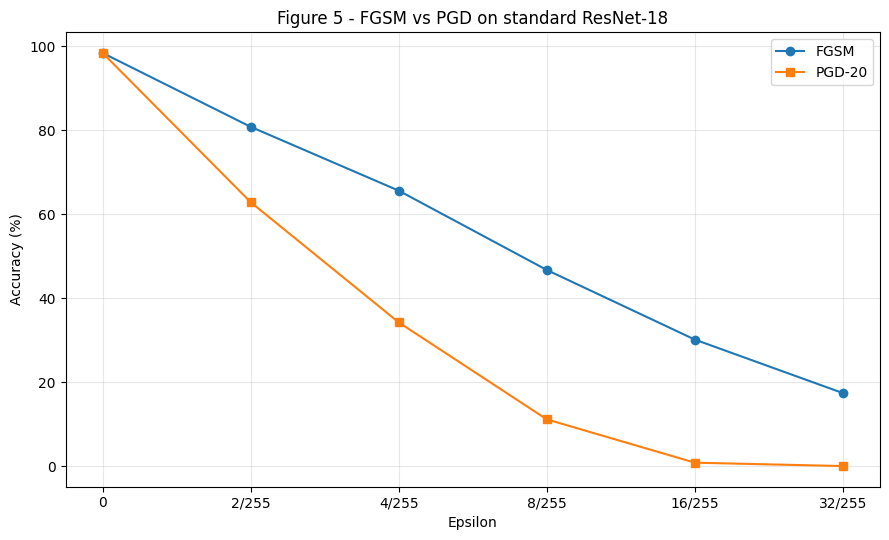

In [70]:
# ==========================================
# Figure 5: FGSM vs PGD curves
# ==========================================
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(EPSILON_LABELS, fgsm_accuracies, marker='o', label='FGSM')
ax.plot(EPSILON_LABELS, pgd_accuracies,  marker='s', label='PGD-20')
ax.set_xlabel('Epsilon')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Figure 5 - FGSM vs PGD on standard ResNet-18')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig5_fgsm_vs_pgd.png'), dpi=120)
plt.show()

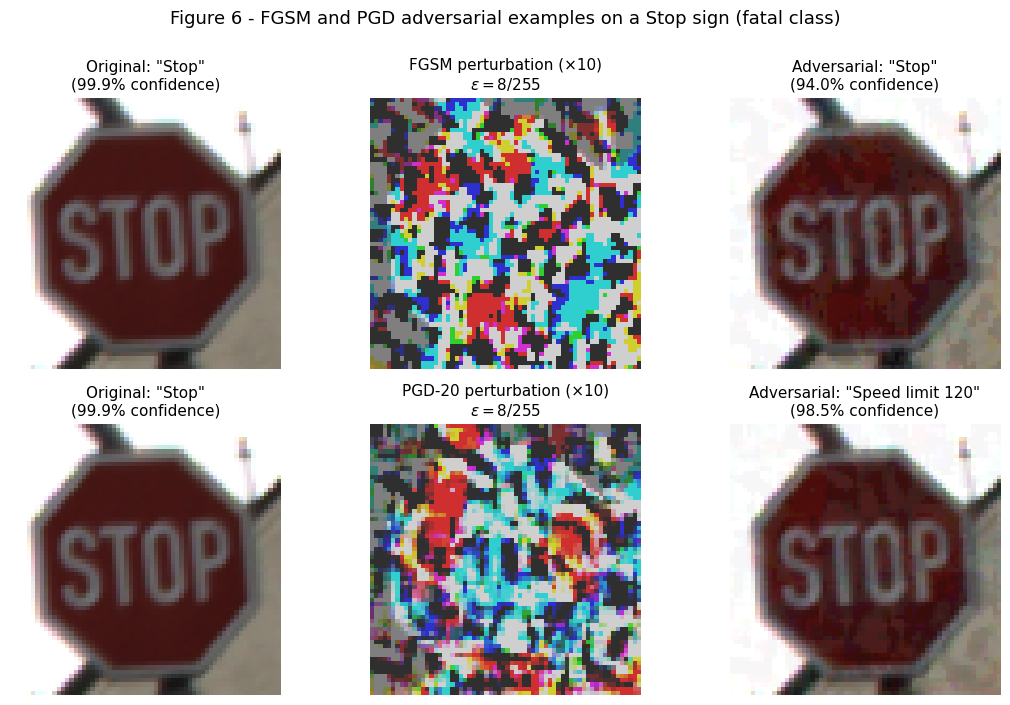


Original Stop sign  ->                           Stop  (99.90% conf)
FGSM adversarial    ->                           Stop  (94.03% conf)
PGD-20 adversarial  ->                Speed limit 120  (98.48% conf)


In [71]:
# ==========================================
# Figure 6: Adversarial example on a Stop sign (fatal class)
# FGSM and PGD-20 side by side
# ==========================================
EPS_VIS = 8/255
STOP_CLASS_ID = 14   # Stop sign

# Find a correctly-classified Stop sign in the test set
mean_t = torch.tensor(MEAN, device=device).view(1, 3, 1, 1)
std_t  = torch.tensor(STD,  device=device).view(1, 3, 1, 1)

model.eval()
stop_img = None
stop_label = None
for img, lbl in testset:
    if lbl != STOP_CLASS_ID:
        continue
    img_b = img.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(img_b).argmax(1).item()
    if pred == STOP_CLASS_ID:    # correctly classified
        stop_img = img_b
        stop_label = torch.tensor([lbl], device=device)
        break

assert stop_img is not None, "No correctly-classified Stop sign found"

# Generate FGSM and PGD-20 adversarial versions
adv_fgsm = fgsm_attack(model, stop_img, stop_label, EPS_VIS)
adv_pgd  = pgd_attack(model,  stop_img, stop_label, EPS_VIS, steps=20, random_start=True)

# Get predictions + confidences on each version
def predict_with_conf(img_norm):
    with torch.no_grad():
        probs = torch.softmax(model(img_norm), dim=1)[0]
    p_id = probs.argmax().item()
    return p_id, probs[p_id].item() * 100

orig_id,  orig_conf  = predict_with_conf(stop_img)
fgsm_id,  fgsm_conf  = predict_with_conf(adv_fgsm)
pgd_id,   pgd_conf   = predict_with_conf(adv_pgd)

# Denormalize back to [0,1] for visualization
def denorm(img_norm):
    return (img_norm * std_t + mean_t).clamp(0, 1).squeeze(0).cpu().permute(1, 2, 0).numpy()

orig_img_vis = denorm(stop_img)
fgsm_img_vis = denorm(adv_fgsm)
pgd_img_vis  = denorm(adv_pgd)

# Perturbations (amplified for visibility)
fgsm_pert = (fgsm_img_vis - orig_img_vis) * 10 + 0.5
pgd_pert  = (pgd_img_vis  - orig_img_vis) * 10 + 0.5
fgsm_pert = np.clip(fgsm_pert, 0, 1)
pgd_pert  = np.clip(pgd_pert,  0, 1)

# Build 2-row figure: FGSM (top row), PGD-20 (bottom row)
fig, axes = plt.subplots(2, 3, figsize=(11, 7))

# Top row — FGSM
axes[0, 0].imshow(orig_img_vis)
axes[0, 0].set_title(f'Original: "{classes[orig_id]}"\n({orig_conf:.1f}% confidence)', fontsize=11)
axes[0, 0].axis('off')

axes[0, 1].imshow(fgsm_pert)
axes[0, 1].set_title(f'FGSM perturbation (×10)\n$\\varepsilon = 8/255$', fontsize=11)
axes[0, 1].axis('off')

axes[0, 2].imshow(fgsm_img_vis)
axes[0, 2].set_title(f'Adversarial: "{classes[fgsm_id]}"\n({fgsm_conf:.1f}% confidence)', fontsize=11)
axes[0, 2].axis('off')

# Bottom row — PGD-20
axes[1, 0].imshow(orig_img_vis)
axes[1, 0].set_title(f'Original: "{classes[orig_id]}"\n({orig_conf:.1f}% confidence)', fontsize=11)
axes[1, 0].axis('off')

axes[1, 1].imshow(pgd_pert)
axes[1, 1].set_title(f'PGD-20 perturbation (×10)\n$\\varepsilon = 8/255$', fontsize=11)
axes[1, 1].axis('off')

axes[1, 2].imshow(pgd_img_vis)
axes[1, 2].set_title(f'Adversarial: "{classes[pgd_id]}"\n({pgd_conf:.1f}% confidence)', fontsize=11)
axes[1, 2].axis('off')

plt.suptitle('Figure 6 - FGSM and PGD adversarial examples on a Stop sign (fatal class)',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig6_adversarial_example_stop.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# Print the prediction shifts
print(f"\nOriginal Stop sign  -> {classes[orig_id]:>30s}  ({orig_conf:.2f}% conf)")
print(f"FGSM adversarial    -> {classes[fgsm_id]:>30s}  ({fgsm_conf:.2f}% conf)")
print(f"PGD-20 adversarial  -> {classes[pgd_id]:>30s}  ({pgd_conf:.2f}% conf)")

# Adversarial Training
Train FGSM-AT and PGD-AT. 50 epochs each.

In [72]:
# ==========================================
# Generic AT training loop
# Early stopping driven by SEVERITY-WEIGHTED F1.
# Fatal recall is also tracked - red flag if it drops below 0.99.
# ==========================================
import time, json as _json

if 'model_best_epochs' not in dir():
    model_best_epochs = {}

def train_adversarial(model, attack_fn, epochs=50, lr_at=0.1,
                       criterion_at=None, name='at_model',
                       elle_lambda=0.0, patience=5):
    if criterion_at is None:
        criterion_at = nn.CrossEntropyLoss()
    opt   = torch.optim.SGD(model.parameters(), lr=lr_at,
                            momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    es    = EarlyStoppingTracker(patience=patience)
    n_batches = len(trainloader)

    print('=' * 60)
    print(f' AT TRAIN: {name}  |  {epochs} epochs  |  {n_batches} batches/epoch')
    print(f' LR={lr_at}  ELLE_lambda={elle_lambda}  patience={patience}')
    print(f' Early stopping metric: severity-weighted F1 (under attack)')
    print('=' * 60)

    history = {'loss': [], 'clean_acc': [], 'robust_acc': [],
               'sw_f1': [], 'fatal_recall': [], 'time': []}
    best_state = None   # snapshot of weights at best epoch (by sw_f1)
    t_start = time.time()
    for epoch in range(epochs):
        t_ep = time.time()
        model.train()
        ep_loss = 0
        for b_idx, (images, labels) in enumerate(trainloader):
            images, labels = images.to(device), labels.to(device)
            adv = attack_fn(model, images, labels)
            opt.zero_grad()
            logits = model(adv)
            loss = criterion_at(logits, labels)
            if elle_lambda > 0:
                loss = loss + elle_lambda * elle_penalty(model, images, adv)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
            if (b_idx + 1) % max(1, n_batches // 4) == 0:
                print(f'    [{name} ep{epoch+1:02d}] batch {b_idx+1:4d}/{n_batches}  '
                      f'running_loss={ep_loss/(b_idx+1):.3f}')
        sched.step()

        # Evaluation on full test set + adversarial test set
        model.eval()
        c_correct = c_total = 0
        rob_t, rob_p = [], []
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            with torch.no_grad():
                c_correct += (model(images).argmax(1) == labels).sum().item()
                c_total   += labels.size(0)
            adv_e = attack_fn(model, images, labels)
            with torch.no_grad():
                preds_adv = model(adv_e).argmax(1)
            rob_t.extend(labels.cpu().numpy())
            rob_p.extend(preds_adv.cpu().numpy())

        clean_acc = 100*c_correct/c_total
        rob_acc   = 100*(np.array(rob_t) == np.array(rob_p)).mean()
        swf1      = severity_weighted_f1(rob_t, rob_p)
        fatalR    = fatal_recall(rob_t, rob_p)

        ep_time = time.time() - t_ep
        elapsed = time.time() - t_start
        history['loss'].append(ep_loss/n_batches)
        history['clean_acc'].append(clean_acc)
        history['robust_acc'].append(rob_acc)
        history['sw_f1'].append(swf1)
        history['fatal_recall'].append(fatalR)
        history['time'].append(elapsed)

        flag = es.step(swf1, epoch)   # ES driven by severity-weighted F1

        # Snapshot best weights
        if flag == 'IMPROVED':
            best_state = {k: v.clone().cpu() for k, v in model.state_dict().items()}

        cur_lr = opt.param_groups[0]['lr']
        tag = ' <- new best' if flag == 'IMPROVED' else ''
        red = '  [RED FLAG: fatal recall below threshold!]' if fatalR < FATAL_RECALL_THRESHOLD else ''
        # Print every 5th epoch + any new-best epoch + any RED FLAG
        if (epoch + 1) % 5 == 0 or flag == 'IMPROVED' or red:
            print(f'  [{name}] Epoch {epoch+1:02d}/{epochs} | loss={ep_loss/n_batches:.3f} | '
                  f'clean={clean_acc:.1f}% | robust={rob_acc:.1f}% | '
                  f'sw_f1={swf1:.3f} | fatal_R={fatalR:.3f} | '
                  f'lr={cur_lr:.4f} | ep={ep_time:.0f}s' + tag + red)

    history['best_epoch']     = es.best_epoch + 1
    history['best_sw_f1']     = es.best_acc
    model_best_epochs[name]   = es.best_epoch + 1

    # Restore best weights so saved checkpoint reflects the best epoch
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f'  [{name}] Restored best weights from epoch {es.best_epoch + 1}')

    torch.save(model.state_dict(), os.path.join(BASE_DIR, name + '.pth'))

    with open(os.path.join(BASE_DIR, name + '_history.json'), 'w') as f:
        _json.dump(history, f, indent=2)
    total_min = (time.time() - t_start) / 60
    print('=' * 60)
    print(f' [{name}] DONE  |  total {total_min:.1f} min  |  best epoch '
          f'{es.best_epoch + 1}  |  best SW-F1 {es.best_acc:.3f}')
    print('=' * 60)
    return history

print('AT training framework ready (ES on severity-weighted F1).')

AT training framework ready (ES on severity-weighted F1).


In [73]:
# ==========================================
# Plot AT training history (loss, accuracy, safety metrics)
# Called after each AT training (FGSM-AT, PGD-AT, FGSM-AT+ELLE, SW-AT+ELLE).
# ==========================================

def plot_at_history(history, name):
    """Visualize loss, clean/robust accuracy, sw_f1 and fatal_recall per epoch."""
    epochs  = range(1, len(history['loss']) + 1)
    best_ep = history['best_epoch']

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # Loss
    axes[0].plot(epochs, history['loss'], marker='o', color='crimson')
    axes[0].axvline(best_ep, color='gray', linestyle='--', label=f'Best epoch = {best_ep}')
    axes[0].set_title(f'{name} - Training Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Clean vs robust accuracy
    axes[1].plot(epochs, history['clean_acc'],  marker='o', label='Clean')
    axes[1].plot(epochs, history['robust_acc'], marker='s', label='Robust')
    axes[1].axvline(best_ep, color='gray', linestyle='--')
    axes[1].set_title(f'{name} - Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    # Safety metrics
    axes[2].plot(epochs, history['sw_f1'],        marker='o', label='Severity-Weighted F1')
    axes[2].plot(epochs, history['fatal_recall'], marker='s', label='Fatal Recall')
    axes[2].axhline(FATAL_RECALL_THRESHOLD, color='red', linestyle=':', alpha=0.5,
                    label=f'Fatal threshold ({FATAL_RECALL_THRESHOLD})')
    axes[2].axvline(best_ep, color='gray', linestyle='--')
    axes[2].set_title(f'{name} - Safety metrics')
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Score')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, f'{name}_history.png'), dpi=120)
    plt.show()

print('plot_at_history defined.')

plot_at_history defined.


## FGSM-AT

Loaded fgsm_at.pth (+ fgsm_at_history.json)


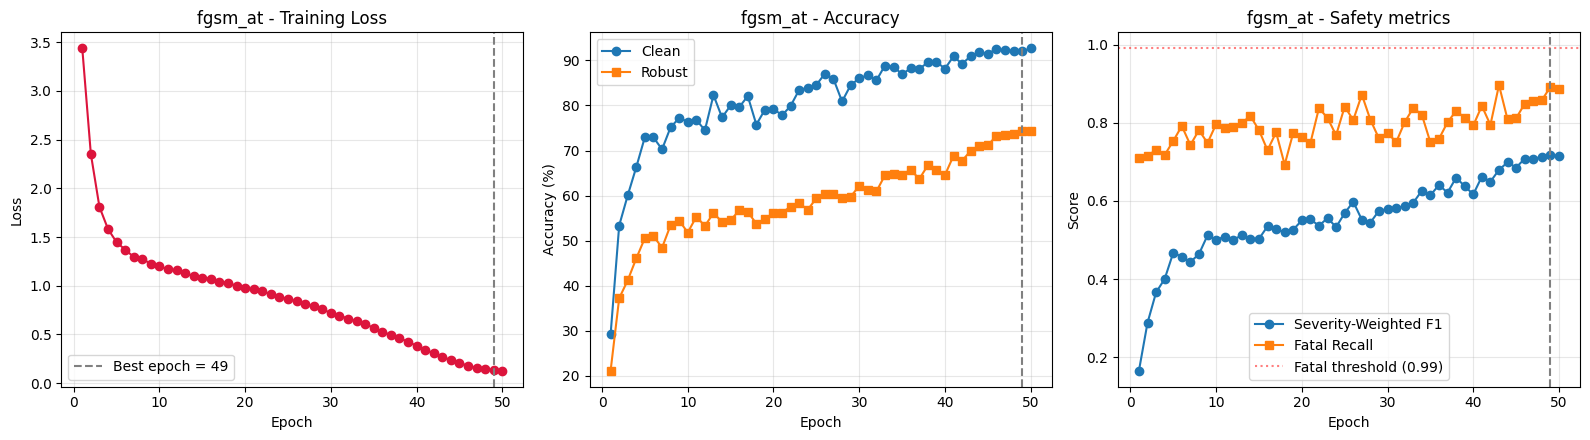

In [74]:
# ==========================================
# Train FGSM-AT — load from checkpoint OR train from scratch
# ==========================================
model_fgsm_at = models.resnet18(weights=None, num_classes=NUM_CLASSES).to(device)

# Standard adversarial budget shared across all AT models (8/255 in pixel space)
EPS_AT = 8/255
fgsm_for_train = lambda m, x, y: fgsm_attack(m, x, y, EPS_AT)

loaded, hist_fgsm_at = try_load_checkpoint(model_fgsm_at, 'fgsm_at.pth', 'fgsm_at_history.json')

if not loaded:
    hist_fgsm_at = train_adversarial(model_fgsm_at, fgsm_for_train,
                                      epochs=50, name='fgsm_at')

plot_at_history(hist_fgsm_at, name='fgsm_at')

## PGD-AT

Loaded pgd_at.pth (+ pgd_at_history.json)


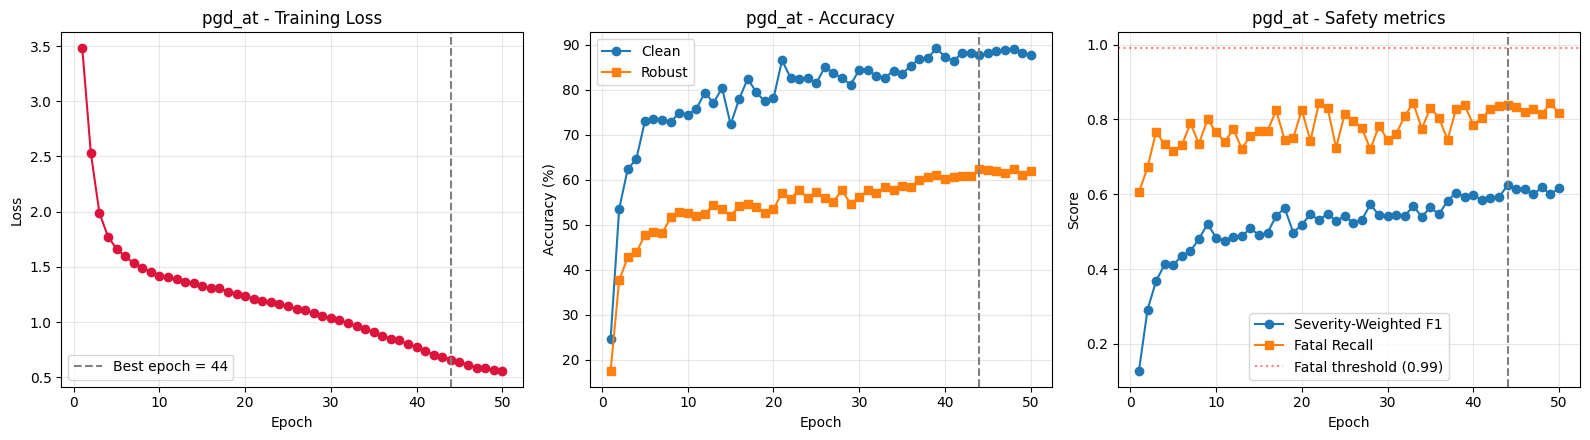

In [75]:
# ==========================================
# Train PGD-AT — load from checkpoint OR train from scratch
# Inner loop: PGD-7 (faster than PGD-20 used for evaluation)
# ==========================================

model_pgd_at = models.resnet18(weights=None, num_classes=NUM_CLASSES).to(device)
pgd_for_train = lambda m, x, y: pgd_attack(m, x, y, EPS_AT, steps=7, random_start=True)

loaded, hist_pgd_at = try_load_checkpoint(model_pgd_at, 'pgd_at.pth', 'pgd_at_history.json')

if not loaded:
    hist_pgd_at = train_adversarial(model_pgd_at, pgd_for_train,
                                     epochs=50, name='pgd_at')

plot_at_history(hist_pgd_at, name='pgd_at')

## ELLE Regularizer and Safety-Weighted Adversarial Training
Implement an ELLE-style regularizer (a variant of Abad Rocamora et al. 2024, see README). Train FGSM-AT+ELLE and SW-AT+ELLE.

In [76]:
# ==========================================
# ELLE-style regularizer (VARIANT - see README, Limitations)
# Penalty: || f(alpha*x_clean + (1-alpha)*x_adv) - alpha*f(x_clean) - (1-alpha)*f(x_adv) ||^2
# on LOGITS, between the clean and FGSM points. The original ELLE
# (Abad Rocamora et al., 2024) penalizes non-linearity of the LOSS between
# points sampled uniformly in the eps-ball.
# ==========================================
def elle_penalty(model, x_clean, x_adv):
    alpha = torch.rand(x_clean.size(0), 1, 1, 1, device=x_clean.device)
    x_mid = alpha * x_clean + (1 - alpha) * x_adv

    f_clean = model(x_clean)
    f_adv   = model(x_adv)
    f_mid   = model(x_mid)

    alpha_flat = alpha.view(-1, 1)
    target = alpha_flat * f_clean + (1 - alpha_flat) * f_adv
    return ((f_mid - target) ** 2).mean()

print('ELLE regularizer defined.')

ELLE regularizer defined.


### Train FGSM-AT + ELLE

Loaded fgsm_at_elle.pth (+ fgsm_at_elle_history.json)


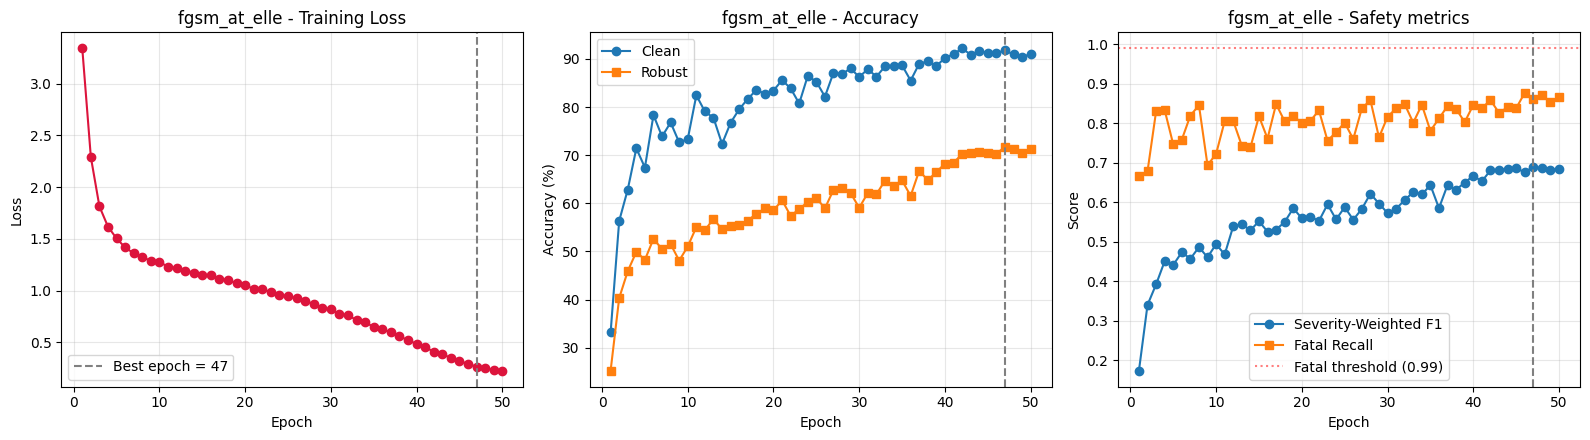

In [77]:
# ==========================================
# Train FGSM-AT + ELLE
# ==========================================

model_fgsm_elle = models.resnet18(weights=None, num_classes=NUM_CLASSES).to(device)

# ELLE-style regularizer added to FGSM-AT loss (lambda=10)
# Intended to prevent catastrophic overfitting by enforcing local linearity between clean and adv inputs

loaded, hist_fgsm_elle = try_load_checkpoint(model_fgsm_elle,
                                              'fgsm_at_elle.pth',
                                              'fgsm_at_elle_history.json')

if not loaded:
    hist_fgsm_elle = train_adversarial(model_fgsm_elle, fgsm_for_train,
                                        epochs=50, name='fgsm_at_elle',
                                        elle_lambda=10.0)

plot_at_history(hist_fgsm_elle, name='fgsm_at_elle')

### Train SW-AT+ELLE

Loaded sw_at_elle.pth (+ sw_at_elle_history.json)


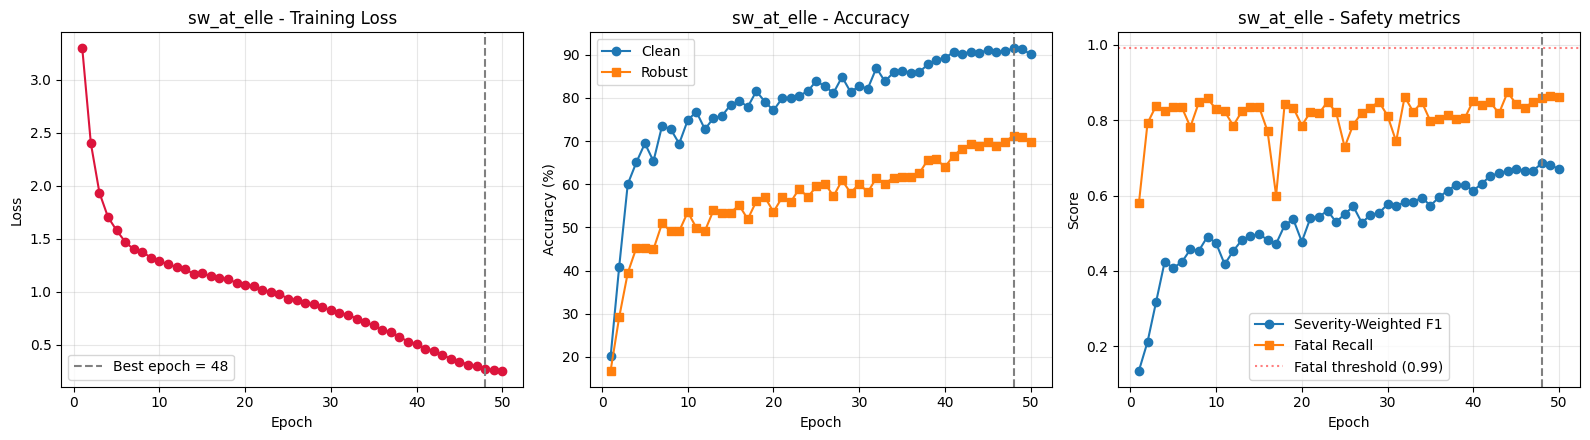

In [78]:
# Safety-severity loss weights: errors on fatal signs (Stop, No entry) hurt 4x more,
# dangerous signs 3x, moderate (speed limits) 2x, minor signs 1x.
# Forces the model to be especially robust on safety-critical classes.
sw_weights = torch.ones(NUM_CLASSES, device=device)
for grp, ids in SAFETY_CLASSES.items():
    if grp == 'minor':
        continue   # minor stays at default weight 1
    for cid in ids:
        sw_weights[cid] = SAFETY_WEIGHTS[grp]
criterion_sw = nn.CrossEntropyLoss(weight=sw_weights)

model_sw_elle = models.resnet18(weights=None, num_classes=NUM_CLASSES).to(device)

# Combines safety-weighted CE loss with the ELLE-style regularizer (lambda=10) on FGSM-AT
loaded, hist_sw_elle = try_load_checkpoint(model_sw_elle,
                                            'sw_at_elle.pth',
                                            'sw_at_elle_history.json')

if not loaded:
    hist_sw_elle = train_adversarial(model_sw_elle, fgsm_for_train,
                                      epochs=50, name='sw_at_elle',
                                      criterion_at=criterion_sw,
                                      elle_lambda=10.0)

plot_at_history(hist_sw_elle, name='sw_at_elle')

In [79]:
# ==========================================
# Best-epoch summary across all trained models
# Use this number to pick a smaller EPOCHS for follow-up runs
# ==========================================

if 'model_best_epochs' in dir() and model_best_epochs:
    print('Per-model convergence:')
    for mname, ep in model_best_epochs.items():
        print(f'  {mname:<20s} -> best epoch {ep}')
    avg = sum(model_best_epochs.values()) / len(model_best_epochs)
    print(f'\nAverage best epoch across {len(model_best_epochs)} model(s): {avg:.1f}')
    import json as _json
    with open(os.path.join(BASE_DIR, 'best_epochs.json'), 'w') as f:
        _json.dump({'per_model': model_best_epochs, 'average': avg}, f, indent=2)
else:
    print('No models trained yet -- train at least one to see this summary.')

Per-model convergence:
  MobileNetV2          -> best epoch 28

Average best epoch across 1 model(s): 28.0


# Evaluation and Analysis

## Evaluation Matrix (5 Models × 3 Attacks)
5 models (Standard, FGSM-AT, FGSM-AT+ELLE, SW-AT+ELLE, PGD-AT) evaluated against Clean, FGSM, and PGD-20.

In [80]:
# ==========================================
# Evaluation utility
# ==========================================

def evaluate_model(model, attack=None, eps=8/255):
    torch.manual_seed(SEED)   # PGD random start: make every evaluation reproducible
    model.eval()
    correct = total = 0
    all_t, all_p = [], []
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        if attack is None:
            adv = images
        elif attack == 'fgsm':
            adv = fgsm_attack(model, images, labels, eps)
        elif attack == 'pgd':
            adv = pgd_attack(model, images, labels, eps, steps=20)
        with torch.no_grad():
            preds = model(adv).argmax(1)
        all_t.extend(labels.cpu().numpy())
        all_p.extend(preds.cpu().numpy())
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return 100*correct/total, all_t, all_p

all_models = {
    'Standard':         model,
    'FGSM-AT':          model_fgsm_at,
    'FGSM-AT+ELLE':     model_fgsm_elle,
    'SW-AT+ELLE':       model_sw_elle,
    'PGD-AT':           model_pgd_at,
}

matrix = {}
preds_store = {}   # store (t, p) per (model, attack) for downstream analyses
for mname, mobj in all_models.items():
    matrix[mname] = {}
    for atk_name, atk in [('Clean', None), ('FGSM', 'fgsm'), ('PGD-20', 'pgd')]:
        acc, t, p = evaluate_model(mobj, attack=atk)
        matrix[mname][atk_name] = acc
        preds_store[(mname, atk_name)] = (t, p)
        print(f'{mname:>14s} | {atk_name:>6s} | {acc:6.2f}%')

# Pretty print the 5x3 matrix
df_5x3 = pd.DataFrame(matrix).T[['Clean','FGSM','PGD-20']]
print('\n5x3 Evaluation Matrix:')
print(df_5x3.round(2))
df_5x3.to_csv(os.path.join(BASE_DIR, 'matrix_5x3.csv'))

      Standard |  Clean |  98.40%
      Standard |   FGSM |  46.71%
      Standard | PGD-20 |  11.31%
       FGSM-AT |  Clean |  92.09%
       FGSM-AT |   FGSM |  74.24%
       FGSM-AT | PGD-20 |  52.88%
  FGSM-AT+ELLE |  Clean |  91.77%
  FGSM-AT+ELLE |   FGSM |  71.71%
  FGSM-AT+ELLE | PGD-20 |  50.52%
    SW-AT+ELLE |  Clean |  91.46%
    SW-AT+ELLE |   FGSM |  71.27%
    SW-AT+ELLE | PGD-20 |  50.87%
        PGD-AT |  Clean |  87.67%
        PGD-AT |   FGSM |  66.85%
        PGD-AT | PGD-20 |  58.54%

5x3 Evaluation Matrix:
              Clean   FGSM  PGD-20
Standard      98.40  46.71   11.31
FGSM-AT       92.09  74.24   52.88
FGSM-AT+ELLE  91.77  71.71   50.52
SW-AT+ELLE    91.46  71.27   50.87
PGD-AT        87.67  66.85   58.54


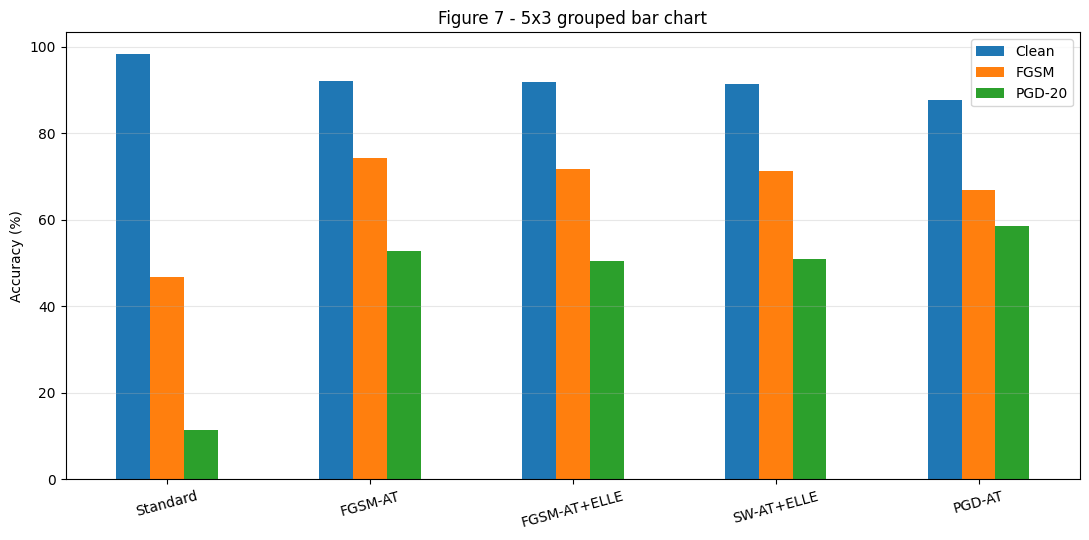

FGSM-PGD gap for FGSM-AT: 21.36 pp
No CO: FGSM-AT keeps 52.88% under PGD-20.
PGD-AT total: 109.6 min
FGSM-AT+ELLE total: 71.6 min
ELLE speedup: 1.53x


In [81]:
# ==========================================
# Figure 7: 5x3 grouped bar chart
# Plus CO check + ELLE speedup
# ==========================================

ax = df_5x3.plot(kind='bar', figsize=(11, 5.5), rot=15)
ax.set_ylabel('Accuracy (%)'); ax.set_title('Figure 7 - 5x3 grouped bar chart')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig7_matrix_bars.png'), dpi=120)
plt.show()

# FGSM-PGD gap for FGSM-AT. NOTE: a gap alone is not a catastrophic-overfitting
# (CO) test - a 15-25 pp gap is normal for a healthy model. CO shows up as PGD
# accuracy collapsing towards 0% (ideally tracked per epoch during training).
co_signal = matrix['FGSM-AT']['FGSM'] - matrix['FGSM-AT']['PGD-20']
print(f'FGSM-PGD gap for FGSM-AT: {co_signal:.2f} pp')
if matrix['FGSM-AT']['PGD-20'] < 10:
    print('PGD accuracy collapsed -> catastrophic overfitting likely in FGSM-AT.')
else:
    print(f"No CO: FGSM-AT keeps {matrix['FGSM-AT']['PGD-20']:.2f}% under PGD-20.")

# ELLE speedup vs PGD-AT
t_pgd  = hist_pgd_at['time'][-1]
t_elle = hist_fgsm_elle['time'][-1]
print(f'PGD-AT total: {t_pgd/60:.1f} min')
print(f'FGSM-AT+ELLE total: {t_elle/60:.1f} min')
print(f'ELLE speedup: {t_pgd/t_elle:.2f}x')

## Direction Analysis, WSCER Comparison, and Grad-CAM Visualization

In [82]:
# ==========================================
# Adversarial direction analysis (Contribution 2)
# Tests the FREQUENCY hypothesis only: do misclassifications go to the
# most frequent training classes more often than their share of the data?
# ==========================================

# Precompute once: top-5 most frequent classes in training set
_train_top_freq = [c for c, _ in _counts.most_common(5)]
# Chance baseline: share of training data that the top-5 classes occupy
_top5_share = sum(_counts[c] for c in _train_top_freq) / sum(_counts.values())
print(f'Chance baseline (top-5 share of training data): {_top5_share:.2f}')

def direction_analysis(true_labels, pred_labels):
    t = np.array(true_labels); p = np.array(pred_labels)
    wrong = t != p
    if wrong.sum() == 0:
        return None
    # Frequency hypothesis: do wrong predictions cluster on most-frequent classes?
    pred_dist = Counter(p[wrong])
    pct_to_top = sum(pred_dist[c] for c in _train_top_freq) / wrong.sum()
    return {'misclassified': int(wrong.sum()),
            'pct_pred_to_top5_freq_classes': float(pct_to_top)}

for mname, _ in all_models.items():
    t, p = preds_store[(mname, 'PGD-20')]
    info = direction_analysis(t, p)
    print(f'{mname:>14s} | wrong={info["misclassified"]:5d}  '
          f'-> top-freq fraction: {info["pct_pred_to_top5_freq_classes"]:.2f}')

Chance baseline (top-5 share of training data): 0.27
      Standard | wrong=11202  -> top-freq fraction: 0.12
       FGSM-AT | wrong= 5951  -> top-freq fraction: 0.15
  FGSM-AT+ELLE | wrong= 6249  -> top-freq fraction: 0.18
    SW-AT+ELLE | wrong= 6205  -> top-freq fraction: 0.22
        PGD-AT | wrong= 5236  -> top-freq fraction: 0.20


      Standard | WSCER under PGD-20: 0.8713
       FGSM-AT | WSCER under PGD-20: 0.4516
  FGSM-AT+ELLE | WSCER under PGD-20: 0.4752
    SW-AT+ELLE | WSCER under PGD-20: 0.4665
        PGD-AT | WSCER under PGD-20: 0.4014


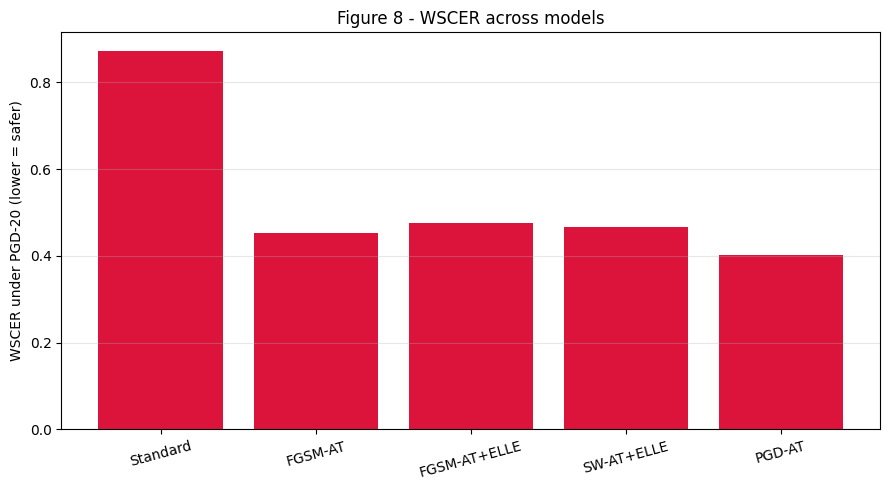

In [83]:
# ==========================================
# WSCER table for all 5 models under PGD-20
# ==========================================

wscer_table = {}
for mname in all_models:
    t, p = preds_store[(mname, 'PGD-20')]
    w, br = compute_wscer(t, p, SAFETY_CLASSES, SAFETY_WEIGHTS)
    wscer_table[mname] = w
    print(f'{mname:>14s} | WSCER under PGD-20: {w:.4f}')

wscer_df = pd.DataFrame.from_dict(wscer_table, orient='index', columns=['WSCER_PGD20'])
wscer_df.to_csv(os.path.join(BASE_DIR, 'wscer_table.csv'))

# Figure 8
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(wscer_df.index, wscer_df['WSCER_PGD20'], color='crimson')
ax.set_ylabel('WSCER under PGD-20 (lower = safer)')
ax.set_title('Figure 8 - WSCER across models')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig8_wscer.png'), dpi=120)
plt.show()

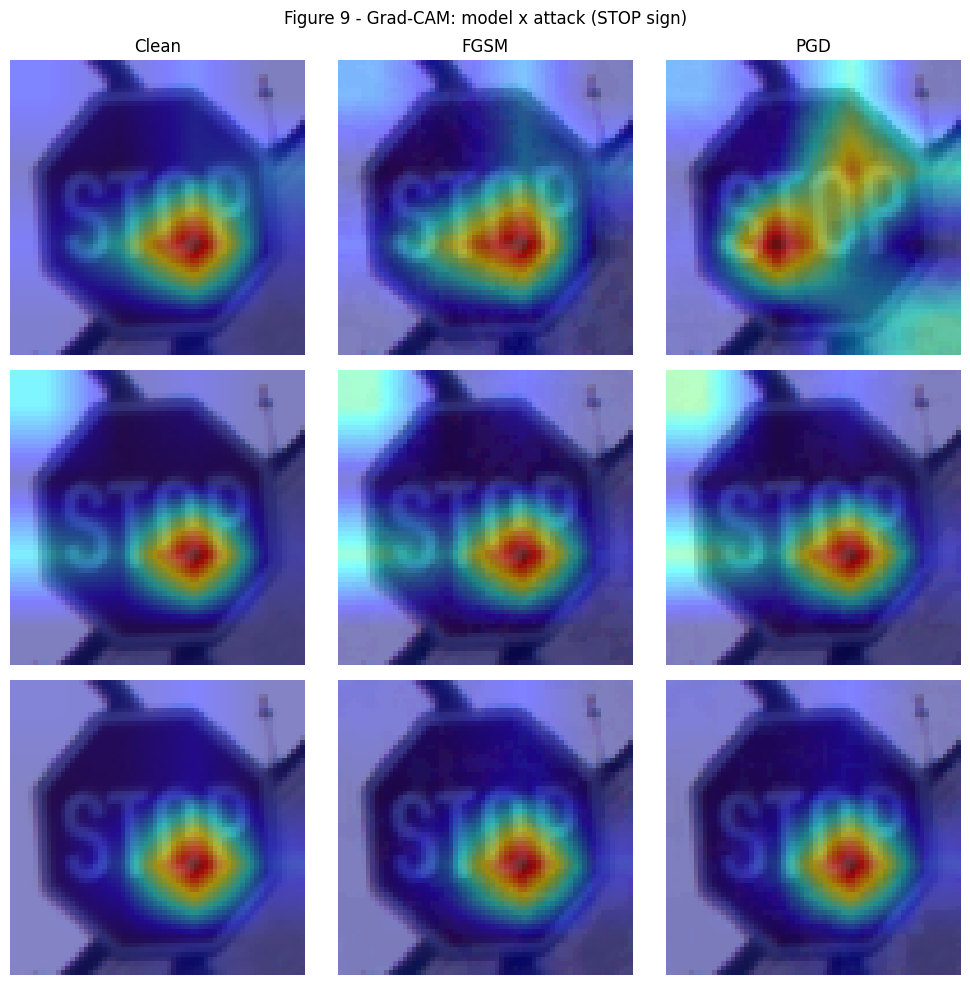

In [84]:
# ==========================================
# Figure 9: Grad-CAM 3x3 (signature figure)
# Rows: Standard / FGSM-AT / PGD-AT
# Cols: Clean / FGSM / PGD
# Subject: a STOP sign (class 14) from the test set
# ==========================================
import cv2
from pytorch_grad_cam.utils.image import show_cam_on_image

# Find a STOP sign sample
stop_idx = next(i for i, (_, l) in enumerate(testset) if l == 14)
img_stop, lbl_stop = testset[stop_idx]
img_stop = img_stop.unsqueeze(0).to(device)
lbl_stop = torch.tensor([lbl_stop]).to(device)

# RGB version for display
img_disp = (img_stop.cpu().squeeze().permute(1,2,0).numpy()
            * np.array(STD) + np.array(MEAN))
img_disp = np.clip(img_disp, 0, 1)

models_grid  = [('Standard', model), ('FGSM-AT', model_fgsm_at), ('PGD-AT', model_pgd_at)]
attacks_grid = [('Clean', None), ('FGSM', 'fgsm'), ('PGD', 'pgd')]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for r, (mname, m) in enumerate(models_grid):
    # layer3[-1]: last block of layer3 (4x4 maps at 64px input).
    # layer4 would give only 2x2 maps, too coarse for a readable heatmap.
    target_layer = [m.layer3[-1]]
    cam = GradCAM(model=m, target_layers=target_layer)
    for c, (aname, atk) in enumerate(attacks_grid):
        if atk is None:
            x = img_stop
        elif atk == 'fgsm':
            x = fgsm_attack(m, img_stop, lbl_stop, 8/255)
        else:
            x = pgd_attack(m, img_stop, lbl_stop, 8/255, steps=20)
        gray = cam(input_tensor=x, targets=[ClassifierOutputTarget(14)])[0]
        x_disp = (x.cpu().detach().squeeze().permute(1,2,0).numpy()
                  * np.array(STD) + np.array(MEAN))
        x_disp = np.clip(x_disp, 0, 1)
        vis = show_cam_on_image(x_disp.astype(np.float32), gray, use_rgb=True)
        axes[r, c].imshow(vis)
        axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(aname)
        if c == 0: axes[r, c].set_ylabel(mname, fontsize=11)
    cam.activations_and_grads.release()   # remove hooks from the model

plt.suptitle('Figure 9 - Grad-CAM: model x attack (STOP sign)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig9_gradcam_3x3.png'), dpi=120)
plt.show()

## Extended Analysis: Safety-Critical Figures, Transferability, and Cross-Dataset Comparison

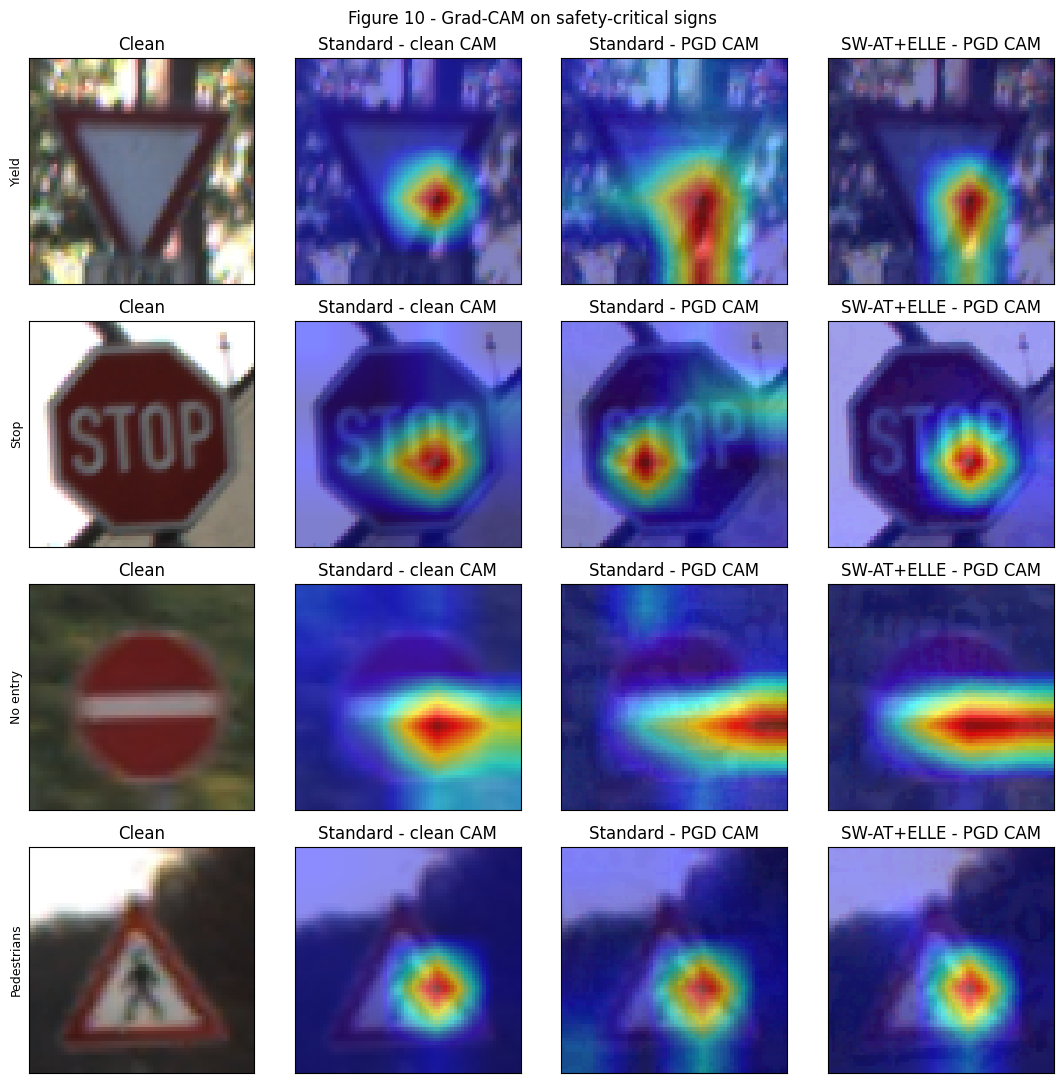

In [85]:
# ==========================================
# Figure 10: Standard vs SW-AT+ELLE on safety-critical signs
# Visualizes Grad-CAM heatmaps on clean and PGD-adversarial inputs
# for 4 safety-critical classes, comparing standard vs robust model
# ==========================================

# Safety-critical class IDs from GTSRB (Fatal/Dangerous severity groups)
critical = [13, 14, 17, 27]   # Yield, Stop, No Entry, Pedestrians

# Grid: one row per critical class, four columns:
# [Clean image | Standard CAM (clean) | Standard CAM (PGD) | SW-AT+ELLE CAM (PGD)]
fig, axes = plt.subplots(len(critical), 4, figsize=(11, 11))

for r, cls_id in enumerate(critical):

    # ── Find the first test image belonging to this class ─────────────
    idx = next(i for i, (_, l) in enumerate(testset) if l == cls_id)
    img, lbl = testset[idx]

    # Add batch dimension and move to device for model inference
    img   = img.unsqueeze(0).to(device)
    lbl_t = torch.tensor([lbl]).to(device)

    # Denormalize for display: reverse (pixel * STD + MEAN) → [0, 1] RGB
    img_d = (img.cpu().squeeze().permute(1, 2, 0).numpy()
             * np.array(STD) + np.array(MEAN))
    img_d = np.clip(img_d, 0, 1)

    # ── Generate PGD adversarial examples for both models ─────────────
    # ε = 8/255 matches the standard ℓ∞ threat model used in RobustBench
    adv_std = pgd_attack(model,         img, lbl_t, 8/255, steps=20)  # Standard model
    adv_sw  = pgd_attack(model_sw_elle, img, lbl_t, 8/255, steps=20)  # Robust model

    # ── Initialise Grad-CAM for each model ────────────────────────────
    # layer3[-1] is the last residual block of layer3 in ResNet-18 (4x4 maps
    # at 64px input); layer4 would only give 2x2 maps
    cam_std = GradCAM(model=model,         target_layers=[model.layer3[-1]])
    cam_sw  = GradCAM(model=model_sw_elle, target_layers=[model_sw_elle.layer3[-1]])

    # ── Compute Grad-CAM heatmaps on adversarial inputs ───────────────
    # ClassifierOutputTarget uses the TRUE class score (not the adversarial prediction)
    g_std = cam_std(input_tensor=adv_std, targets=[ClassifierOutputTarget(cls_id)])[0]
    g_sw  = cam_sw (input_tensor=adv_sw,  targets=[ClassifierOutputTarget(cls_id)])[0]

    # Denormalize adversarial images for display (same pipeline as clean image)
    adv_std_d = np.clip(
        adv_std.cpu().detach().squeeze().permute(1, 2, 0).numpy()
        * np.array(STD) + np.array(MEAN), 0, 1
    ).astype(np.float32)

    adv_sw_d = np.clip(
        adv_sw.cpu().detach().squeeze().permute(1, 2, 0).numpy()
        * np.array(STD) + np.array(MEAN), 0, 1
    ).astype(np.float32)

    # ── Populate the four columns for this row ────────────────────────

    # Col 0 — Clean input image (no attack, no CAM overlay)
    axes[r, 0].imshow(img_d)
    axes[r, 0].set_title('Clean')

    # Col 1 — Standard model Grad-CAM on the clean image
    # Shows what the standard model focuses on under normal conditions
    clean_cam_std = cam_std(input_tensor=img,
                            targets=[ClassifierOutputTarget(cls_id)])[0]
    axes[r, 1].imshow(show_cam_on_image(img_d.astype(np.float32),
                                        clean_cam_std, use_rgb=True))
    axes[r, 1].set_title('Standard - clean CAM')

    # Col 2 — Standard model Grad-CAM on its own PGD adversarial example
    # Expected: heatmap shifts away from the sign (model is confused)
    axes[r, 2].imshow(show_cam_on_image(adv_std_d, g_std, use_rgb=True))
    axes[r, 2].set_title('Standard - PGD CAM')

    # Col 3 — SW-AT+ELLE model Grad-CAM on its own PGD adversarial example
    # Expected: heatmap stays focused on the sign (robust model resists attack)
    axes[r, 3].imshow(show_cam_on_image(adv_sw_d, g_sw, use_rgb=True))
    axes[r, 3].set_title('SW-AT+ELLE - PGD CAM')

    # Remove tick marks from all four subplots in this row
    for a in axes[r]:
        a.set_yticks([])
        a.set_xticks([])

    # Label the row with the human-readable class name on the leftmost column
    axes[r, 0].set_ylabel(classes[cls_id], fontsize=9)

    # Remove Grad-CAM hooks so they don't stay attached to the models
    cam_std.activations_and_grads.release()
    cam_sw.activations_and_grads.release()

plt.suptitle('Figure 10 - Grad-CAM on safety-critical signs', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig10_gradcam_critical.png'), dpi=120)
plt.show()

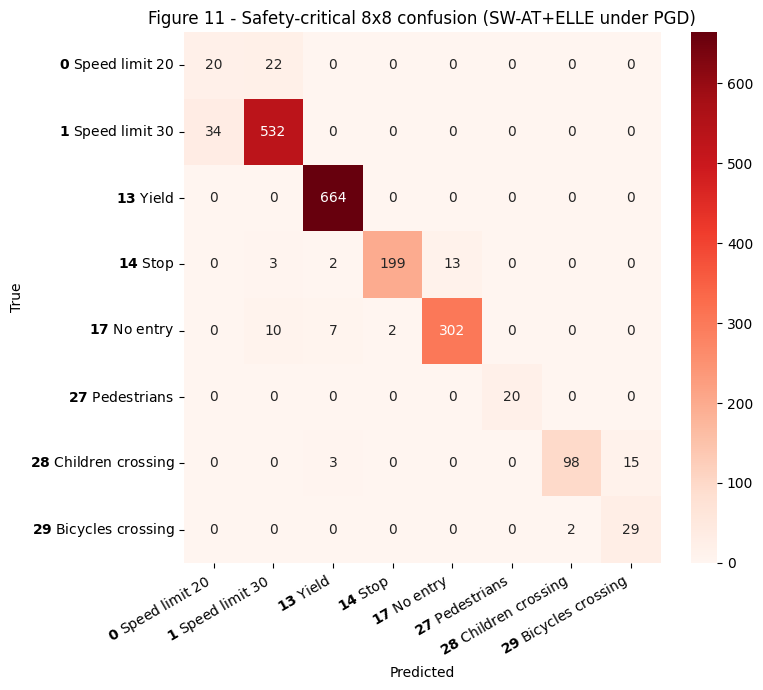

In [86]:
# ==========================================
# Figure 11: 8x8 safety-critical confusion submatrix
# ==========================================
import seaborn as sns

critical_ids = sorted(set(
    SAFETY_CLASSES['fatal']
    + SAFETY_CLASSES['dangerous']
    + SAFETY_CLASSES['moderate'][:2]
))

t_b, p_b = preds_store[('SW-AT+ELLE', 'PGD-20')]
cm_full = confusion_matrix(t_b, p_b, labels=list(range(NUM_CLASSES)))
cm_8 = cm_full[np.ix_(critical_ids, critical_ids)]

labels_bold_8 = [r'$\bf{' + str(i) + r'}$ ' + classes[i] for i in critical_ids]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_8, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels_bold_8, yticklabels=labels_bold_8, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Figure 11 - Safety-critical 8x8 confusion (SW-AT+ELLE under PGD)')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'fig11_safety_8x8.png'), dpi=120)
plt.show()

In [87]:
# ==========================================
# Transferability: ResNet-18 -> MobileNetV2
# ==========================================

model.eval(); model_b.eval()
trans_correct = trans_total = 0
for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    adv = pgd_attack(model, images, labels, 8/255, steps=20)
    with torch.no_grad():
        preds = model_b(adv).argmax(1)
    trans_correct += (preds == labels).sum().item()
    trans_total   += labels.size(0)

transfer_acc = 100 * trans_correct / trans_total
print(f'Transferability ResNet-18 -> MobileNetV2 (PGD): MobileNet acc = {transfer_acc:.2f}%')
print(f'Attack success rate: {100 - transfer_acc:.2f}%')

Transferability ResNet-18 -> MobileNetV2 (PGD): MobileNet acc = 72.15%
Attack success rate: 27.85%


In [88]:
# ==========================================
# Macro-F1 + classification report (extended metrics)
# ==========================================
from sklearn.metrics import f1_score

ext_metrics = {}
for mname in all_models:
    row = {}
    for atk_name in ['Clean', 'FGSM', 'PGD-20']:
        t, p = preds_store[(mname, atk_name)]
        row[atk_name + '_macroF1'] = f1_score(t, p, average='macro')
    ext_metrics[mname] = row

ext_df = pd.DataFrame(ext_metrics).T
print(ext_df.round(3))
ext_df.to_csv(os.path.join(BASE_DIR, 'macro_f1_table.csv'))

              Clean_macroF1  FGSM_macroF1  PGD-20_macroF1
Standard              0.975         0.442           0.121
FGSM-AT               0.906         0.708           0.503
FGSM-AT+ELLE          0.906         0.684           0.484
SW-AT+ELLE            0.905         0.678           0.485
PGD-AT                0.863         0.657           0.575


In [89]:
# ==========================================
# Cross-dataset comparison (CIFAR-10 vs GTSRB)
# Reuses CIFAR-10 numbers from your AI Project 
# ==========================================

cross = pd.DataFrame({
    'CIFAR-10': {'Clean': None, 'FGSM_eps8': None, 'PGD_eps8': None,
                 'CO_drop_pp': 0.94},   # from AI Project
    'GTSRB':    {'Clean':     matrix['Standard']['Clean'],
                 'FGSM_eps8': matrix['Standard']['FGSM'],
                 'PGD_eps8':  matrix['Standard']['PGD-20'],
                 'CO_drop_pp': co_signal}
})
print('Cross-dataset comparison:')
print(cross)
cross.to_csv(os.path.join(BASE_DIR, 'cross_dataset.csv'))

Cross-dataset comparison:
            CIFAR-10      GTSRB
Clean            NaN  98.400633
FGSM_eps8        NaN  46.706255
PGD_eps8         NaN  11.306413
CO_drop_pp      0.94  21.361837


In [90]:
# Bundle all generated artifacts into a downloadable zip
import zipfile, glob

# List every artifact produced by the notebook: model checkpoints (.pth),
# training histories (.json), evaluation tables (.csv), and figures (.png)
artifacts = sorted(glob.glob(os.path.join(BASE_DIR, '*')))

print(f"Contents of {BASE_DIR}:")
print("-" * 60)
total_size_mb = 0
for path in artifacts:
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        total_size_mb += size_mb
        print(f"  {os.path.basename(path):<35s} {size_mb:>8.2f} MB")
print("-" * 60)
print(f"  TOTAL{'':<31s} {total_size_mb:>8.2f} MB\n")

# Bundle everything into a single archive for one-click download from Kaggle UI.
# Kaggle persists /kaggle/working/ only after Save Version — without a commit,
# all files (including this zip) will be lost when the session ends.
zip_path = '/kaggle/working/led_project_all.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for path in artifacts:
        if os.path.isfile(path):
            # Store paths relative to /kaggle/working so the zip extracts cleanly
            arcname = os.path.relpath(path, '/kaggle/working')
            zf.write(path, arcname)

zip_size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f"Created archive: {zip_path}  ({zip_size_mb:.2f} MB)")
print("Download via Kaggle 'Output' tab -> led_project_all.zip")

Contents of /kaggle/working/led_project:
------------------------------------------------------------
  baselines_comparison_curves.png         0.08 MB
  best_epochs.json                        0.00 MB
  config.yaml                             0.00 MB
  confusion_full_43.png                   0.22 MB
  confusion_safety_8x8.png                0.12 MB
  cross_dataset.csv                       0.00 MB
  fgsm_at.pth                            42.79 MB
  fgsm_at_elle.pth                       42.80 MB
  fgsm_at_elle_history.json               0.01 MB
  fgsm_at_elle_history.png                0.11 MB
  fgsm_at_history.json                    0.01 MB
  fgsm_at_history.png                     0.11 MB
  fig10_gradcam_critical.png              0.26 MB
  fig10_wscer.png                         0.04 MB
  fig11_safety_8x8.png                    0.08 MB
  fig1_class_distribution.png             0.13 MB
  fig3_fgsm_vs_pgd.png                    0.06 MB
  fig4_class_size_vs_robustness.png       0.06 M